___
# Project - Part #2

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Exploratory Data Analysis part

In [2]:
data = pd.read_csv("dataset/dataset.csv")
data.shape

(920, 32)

In [3]:
data.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,female,...,thal_fixed_defect,thal_normal,thal_reversable_defect,thal_unknown,slope_downsloping,slope_flat,slope_unknown,slope_upsloping,ca_was_missing,chol_missing
0,63,145,233,1,150,0,2.3,0,0,0,...,1,0,0,0,1,0,0,0,0,0
1,67,160,286,0,108,1,1.5,3,2,0,...,0,1,0,0,0,1,0,0,0,0
2,67,120,229,0,129,1,2.6,2,1,0,...,0,0,1,0,0,1,0,0,0,0
3,37,130,250,0,187,0,3.5,0,0,0,...,0,1,0,0,1,0,0,0,0,0
4,41,130,204,0,172,0,1.4,0,0,1,...,0,1,0,0,0,0,0,1,0,0


### Here I do pearson statistical test to detect if any variable have possibility for linear correlation with any other dependant variable (or target)

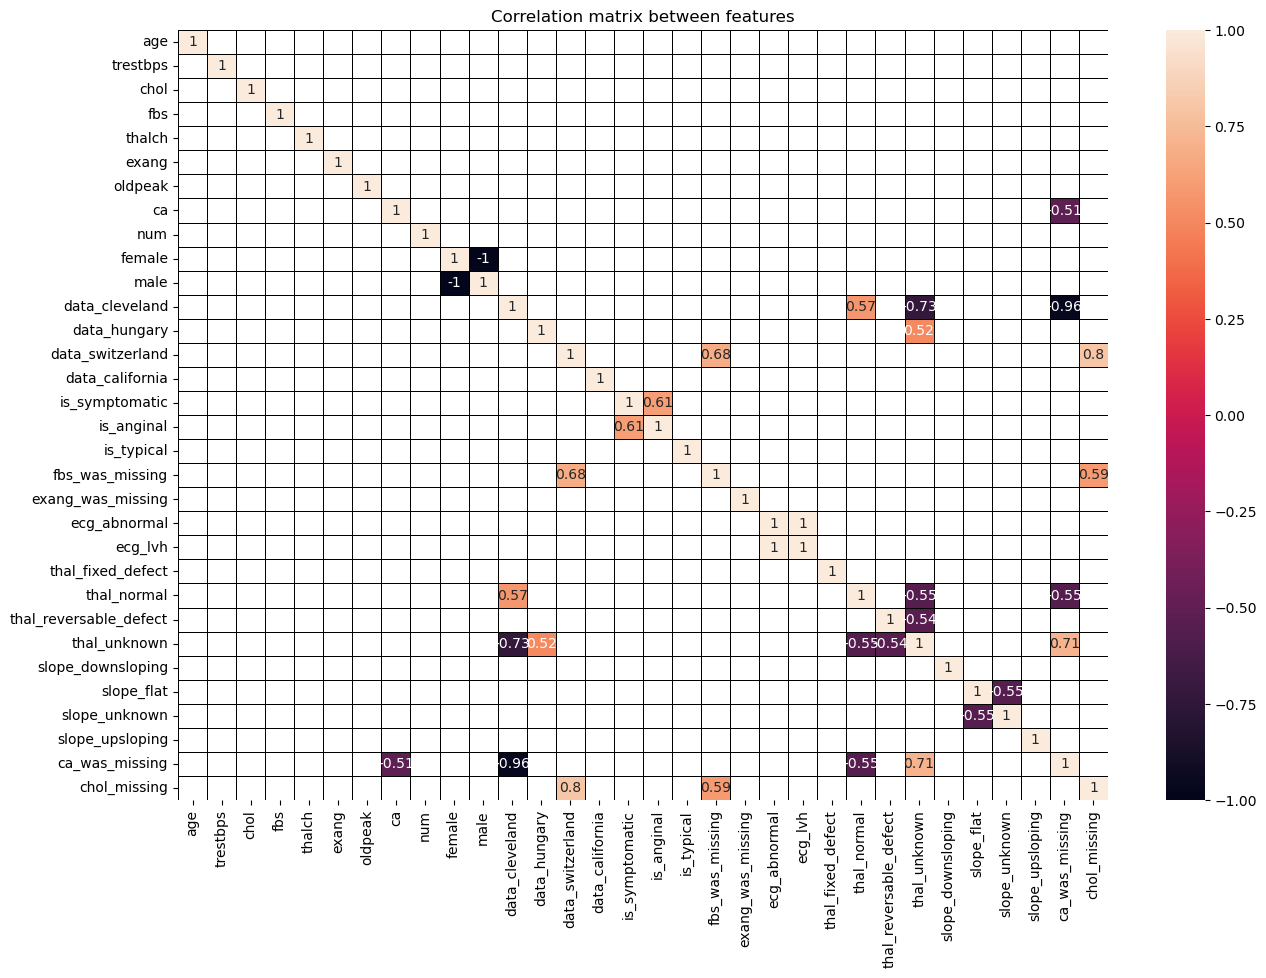

In [4]:
corr = data.corr()
mask = corr.abs() <= 0.5
plt.figure(figsize=(15, 10))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, linecolor='black' )
plt.title("Correlation matrix between features")
plt.show()


In [5]:
correlations = data.corr()['num'].abs().sort_values(ascending=False)
print(correlations)

num                       1.000000
oldpeak                   0.442416
is_symptomatic            0.424172
data_hungary              0.379413
exang                     0.363997
thalch                    0.360859
is_anginal                0.343708
age                       0.339596
chol_missing              0.288574
data_switzerland          0.278355
thal_reversable_defect    0.278313
ca                        0.261797
male                      0.259342
female                    0.259342
slope_flat                0.242790
data_california           0.241977
slope_unknown             0.218959
thal_normal               0.216512
slope_downsloping         0.178142
slope_upsloping           0.142565
trestbps                  0.139245
fbs                       0.129539
fbs_was_missing           0.126196
thal_fixed_defect         0.105679
thal_unknown              0.095111
exang_was_missing         0.077233
ecg_lvh                   0.075099
ecg_abnormal              0.075099
is_typical          

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     920 non-null    int64  
 1   trestbps                920 non-null    int64  
 2   chol                    920 non-null    int64  
 3   fbs                     920 non-null    int64  
 4   thalch                  920 non-null    int64  
 5   exang                   920 non-null    int64  
 6   oldpeak                 920 non-null    float64
 7   ca                      920 non-null    int64  
 8   num                     920 non-null    int64  
 9   female                  920 non-null    int64  
 10  male                    920 non-null    int64  
 11  data_cleveland          920 non-null    int64  
 12  data_hungary            920 non-null    int64  
 13  data_switzerland        920 non-null    int64  
 14  data_california         920 non-null    in

In [7]:
data.describe()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,female,...,thal_fixed_defect,thal_normal,thal_reversable_defect,thal_unknown,slope_downsloping,slope_flat,slope_unknown,slope_upsloping,ca_was_missing,chol_missing
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,...,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.00000,920.000000,920.00000,920.000000
mean,53.510870,132.418478,243.588043,0.150000,137.226087,0.390217,0.900206,0.227174,0.995652,0.210870,...,0.050000,0.213043,0.208696,0.528261,0.068478,0.375000,0.33587,0.220652,0.66413,0.193478
std,9.424685,17.969987,52.507887,0.357266,25.512782,0.488064,1.036320,0.628936,1.142693,0.408148,...,0.218063,0.409681,0.406597,0.499472,0.252702,0.484386,0.47255,0.414912,0.47255,0.395239
min,28.000000,80.000000,85.000000,0.000000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000
50%,54.000000,130.000000,237.000000,0.000000,140.000000,0.000000,0.600000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,1.00000,0.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.000000,1.500000,0.000000,2.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,0.000000,1.00000,0.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,1.000000,6.200000,3.000000,4.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000


#### The youngest person --> 28 years old
#### The oldest ---> 77 years old

--- Analyzing column: age ---
count    920.000000
mean      53.510870
std        9.424685
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: age, dtype: float64


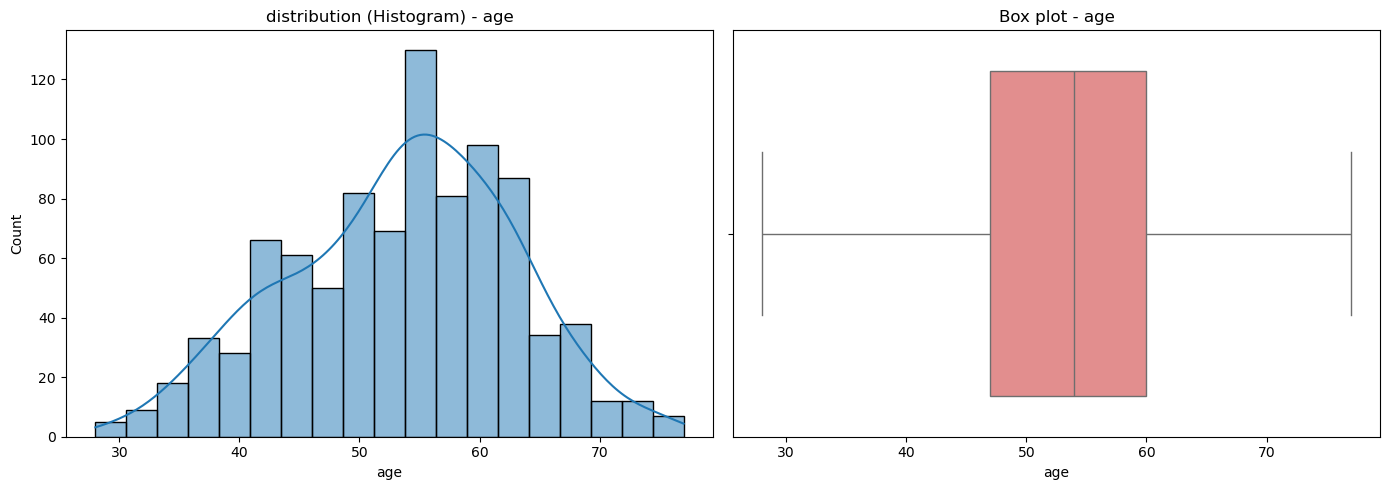

--- Analyzing column: trestbps ---
count    920.000000
mean     132.418478
std       17.969987
min       80.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64


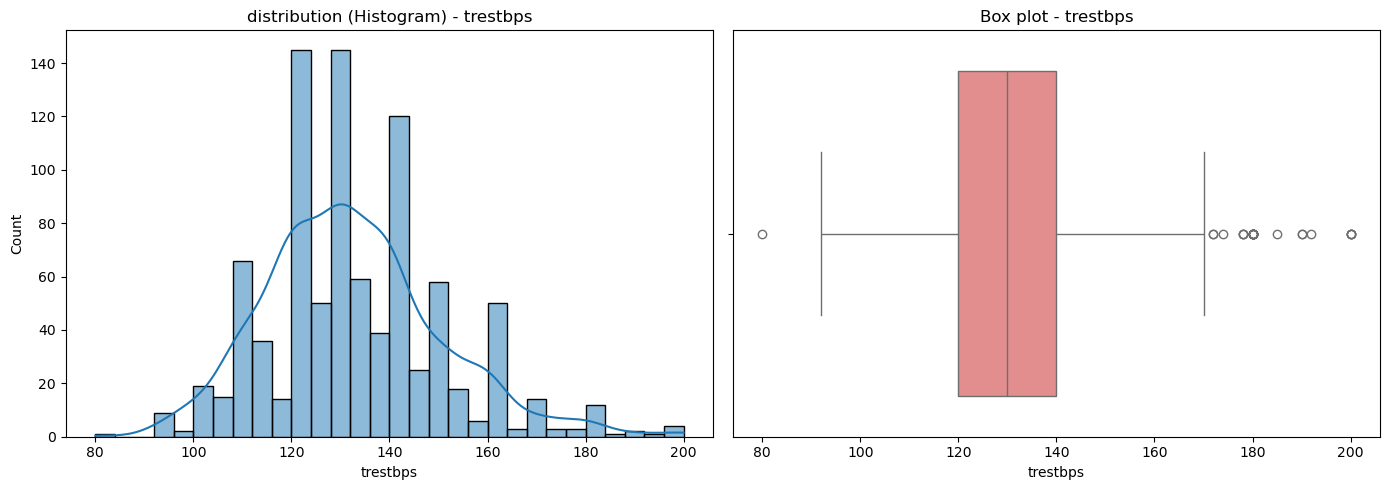

--- Analyzing column: chol ---
count    920.000000
mean     243.588043
std       52.507887
min       85.000000
25%      214.000000
50%      237.000000
75%      267.000000
max      603.000000
Name: chol, dtype: float64


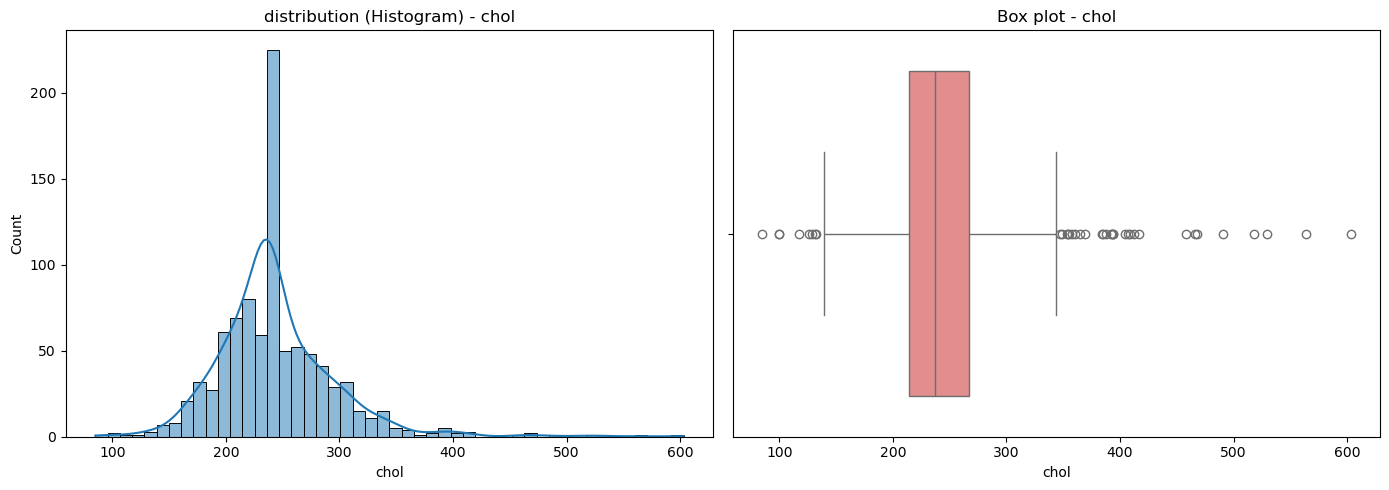

--- Analyzing column: fbs ---
count    920.000000
mean       0.150000
std        0.357266
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: fbs, dtype: float64


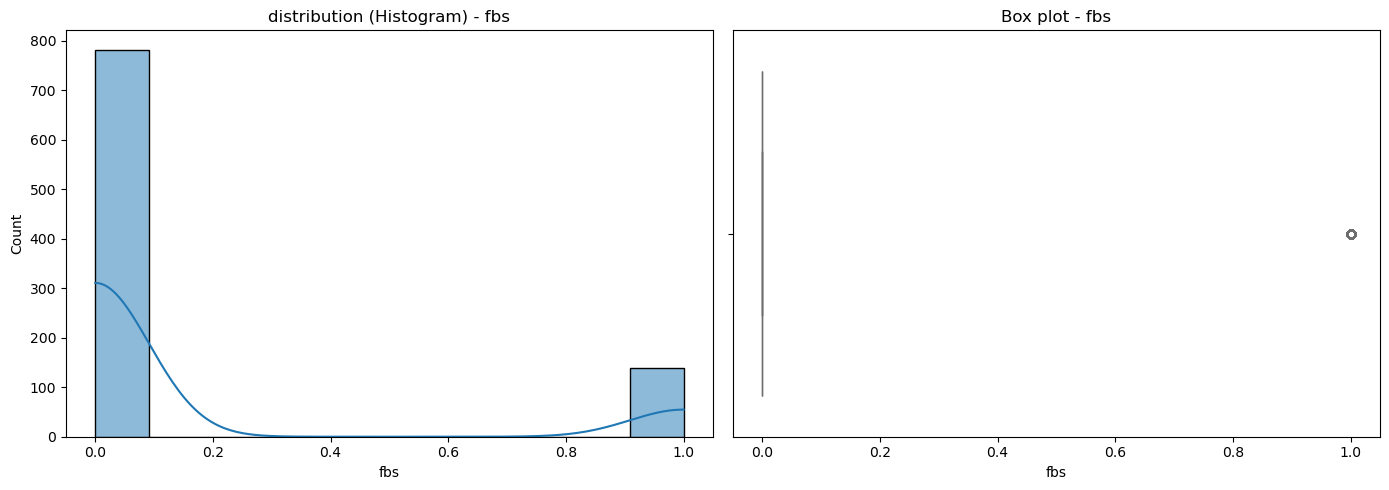

--- Analyzing column: thalch ---
count    920.000000
mean     137.226087
std       25.512782
min       60.000000
25%      120.000000
50%      140.000000
75%      156.000000
max      202.000000
Name: thalch, dtype: float64


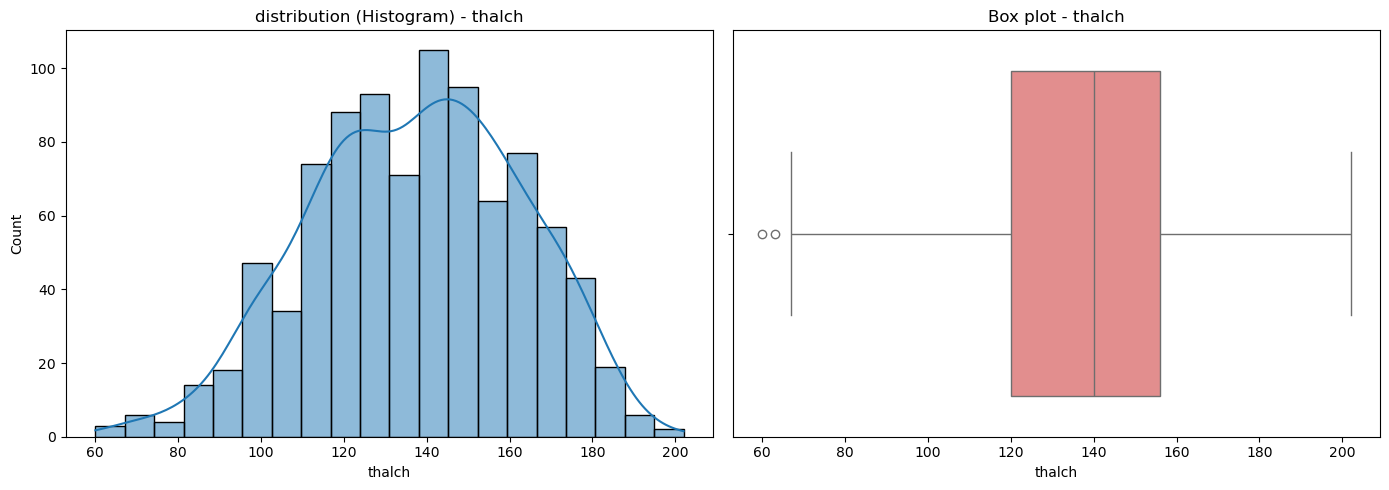

--- Analyzing column: exang ---
count    920.000000
mean       0.390217
std        0.488064
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: exang, dtype: float64


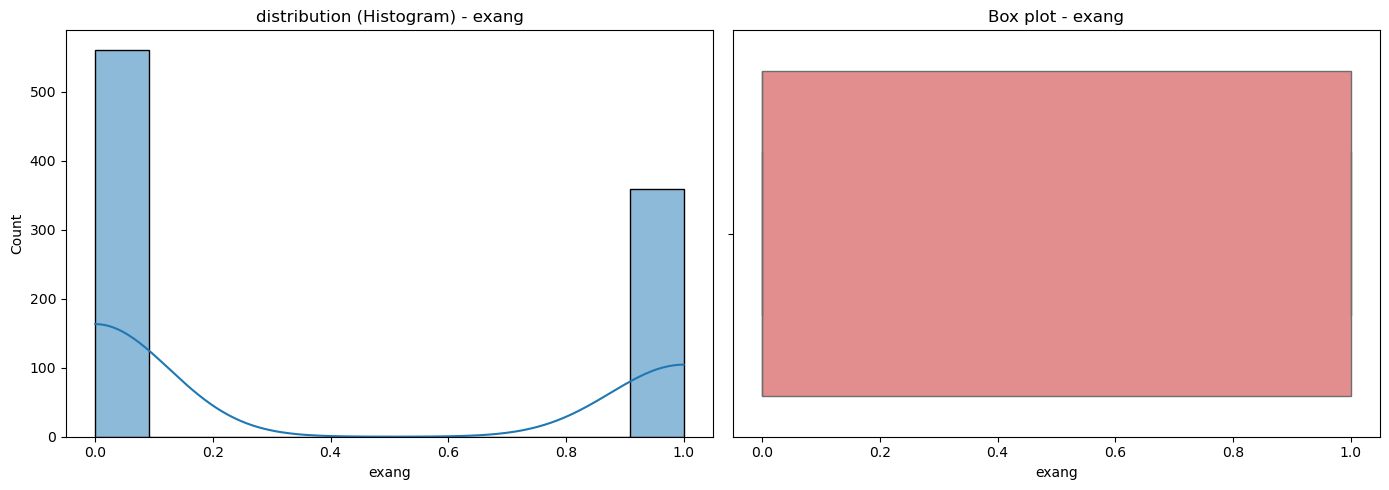

--- Analyzing column: oldpeak ---
count    920.000000
mean       0.900206
std        1.036320
min        0.000000
25%        0.000000
50%        0.600000
75%        1.500000
max        6.200000
Name: oldpeak, dtype: float64


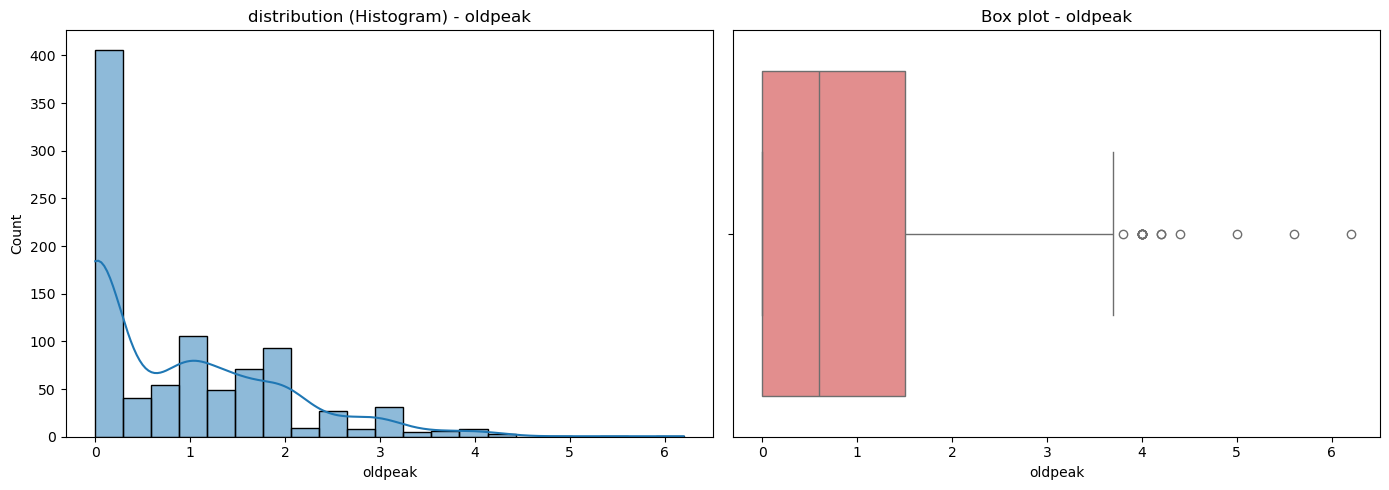

--- Analyzing column: ca ---
count    920.000000
mean       0.227174
std        0.628936
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        3.000000
Name: ca, dtype: float64


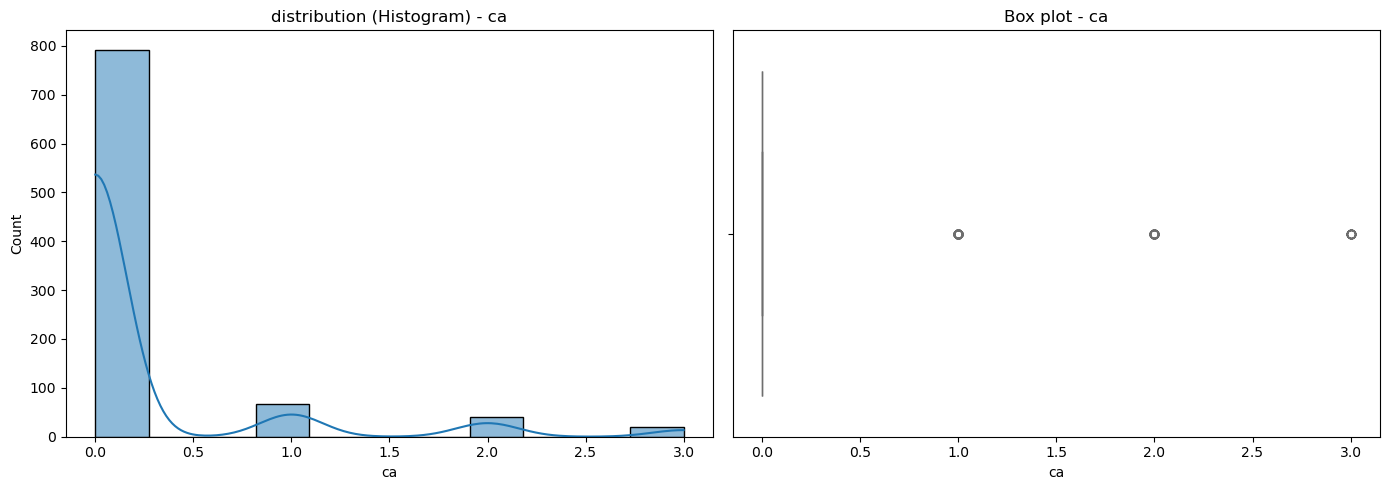

--- Analyzing column: num ---
count    920.000000
mean       0.995652
std        1.142693
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max        4.000000
Name: num, dtype: float64


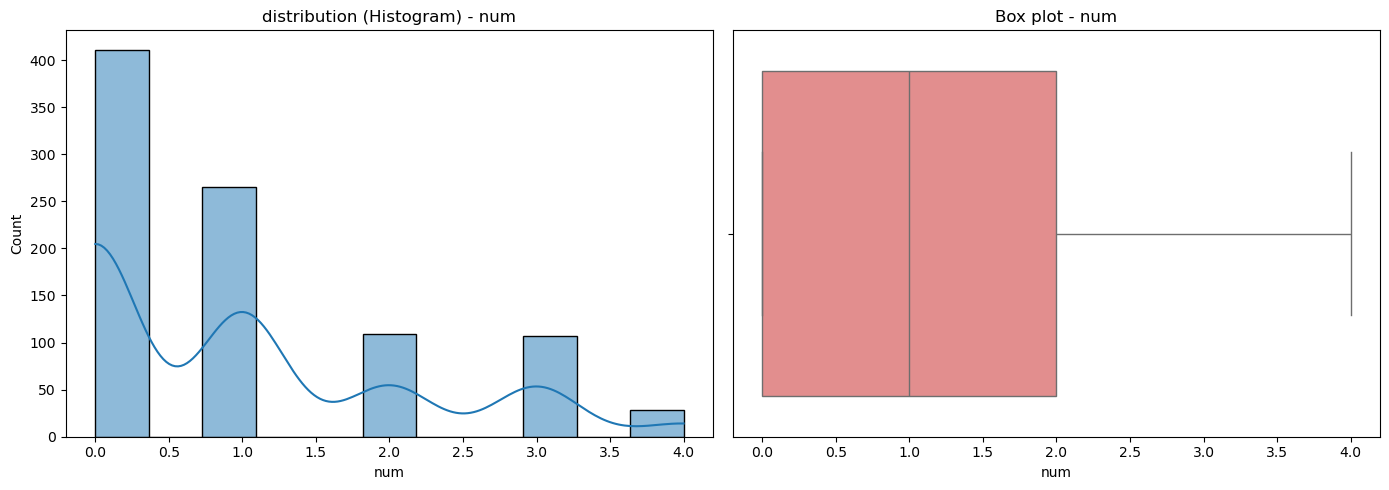

--- Analyzing column: female ---
count    920.000000
mean       0.210870
std        0.408148
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: female, dtype: float64


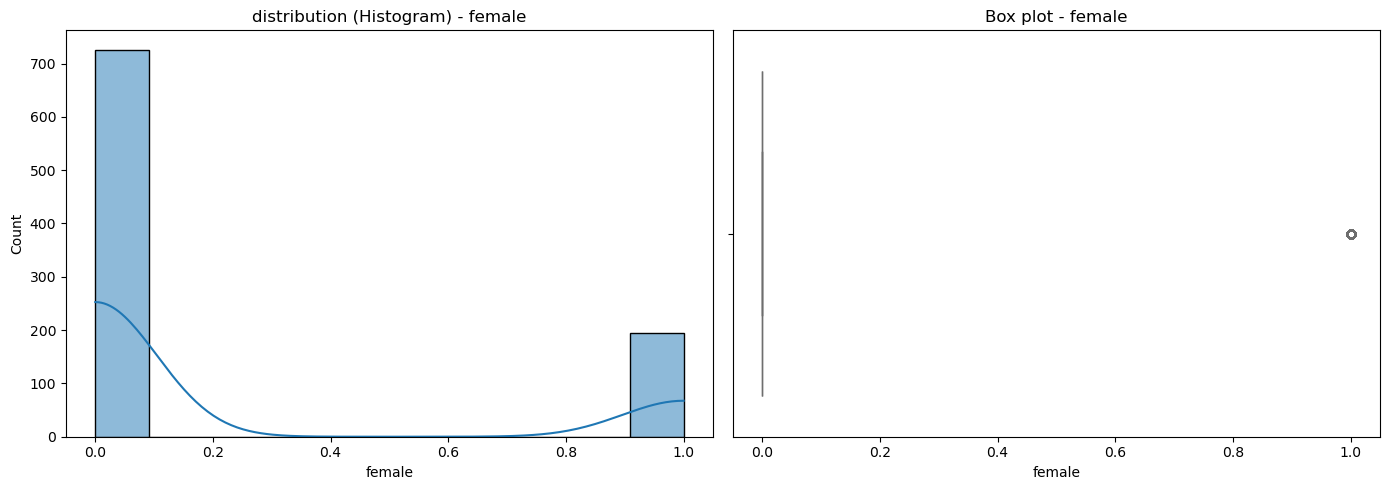

--- Analyzing column: male ---
count    920.000000
mean       0.789130
std        0.408148
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: male, dtype: float64


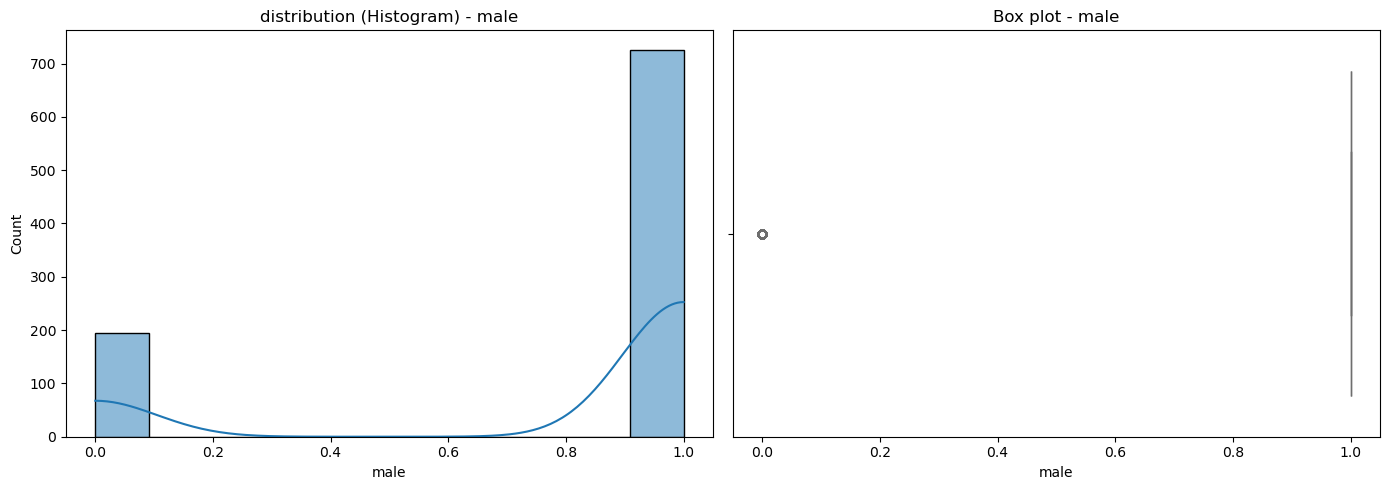

--- Analyzing column: data_cleveland ---
count    920.000000
mean       0.330435
std        0.470626
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: data_cleveland, dtype: float64


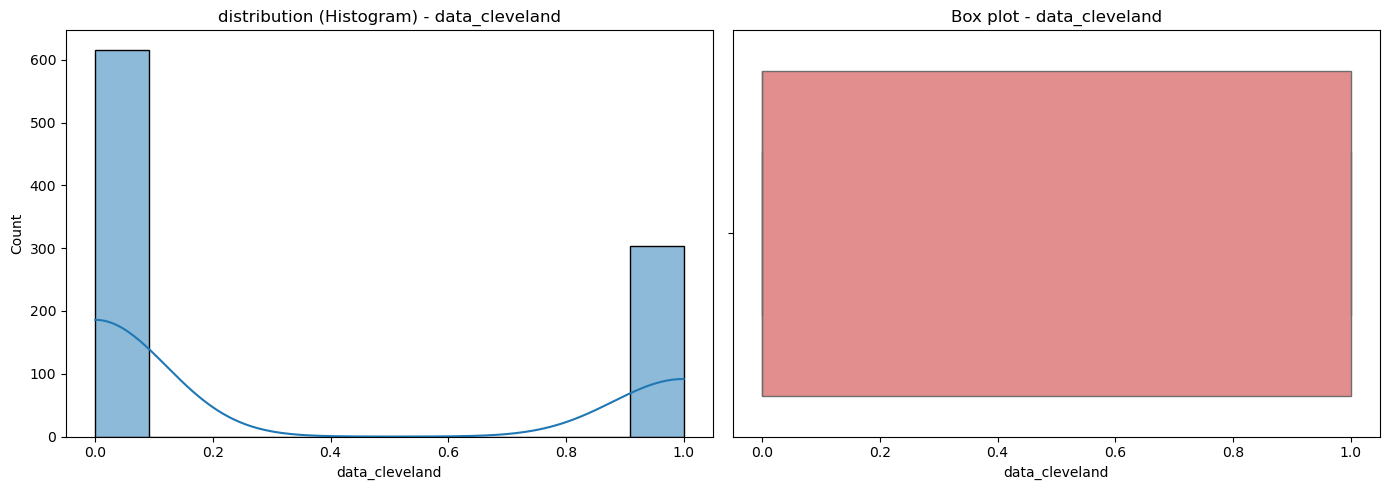

--- Analyzing column: data_hungary ---
count    920.000000
mean       0.318478
std        0.466140
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: data_hungary, dtype: float64


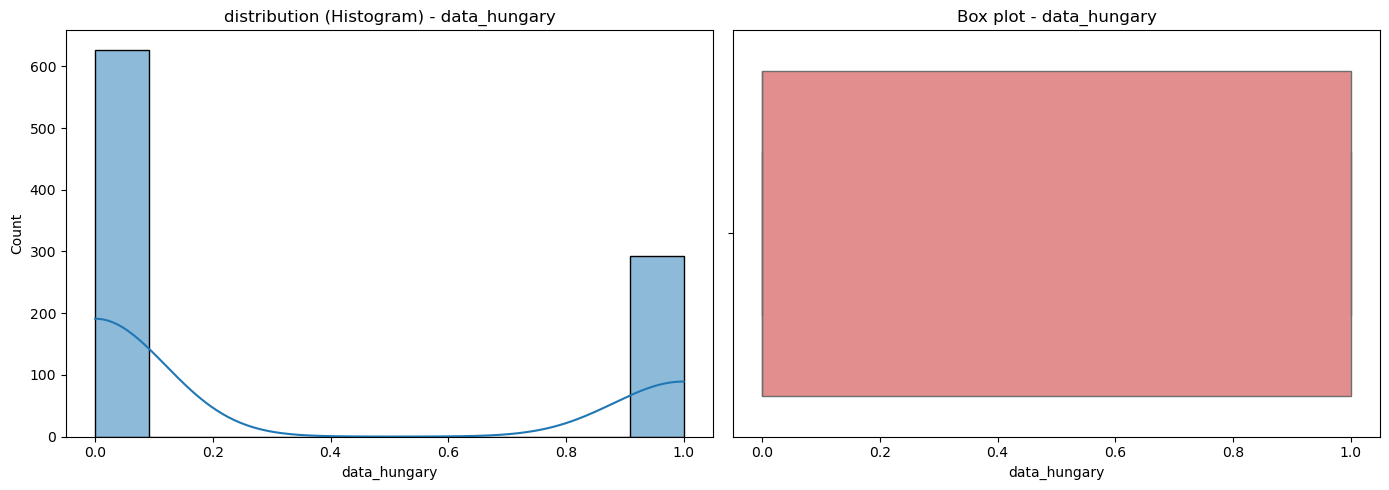

--- Analyzing column: data_switzerland ---
count    920.000000
mean       0.133696
std        0.340510
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: data_switzerland, dtype: float64


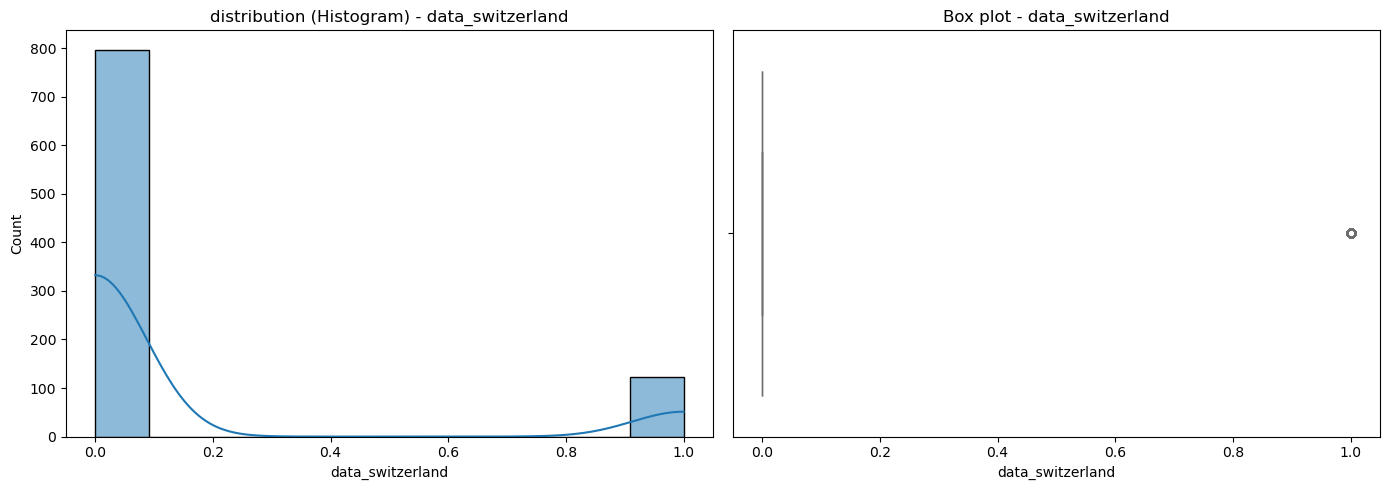

--- Analyzing column: data_california ---
count    920.000000
mean       0.217391
std        0.412695
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: data_california, dtype: float64


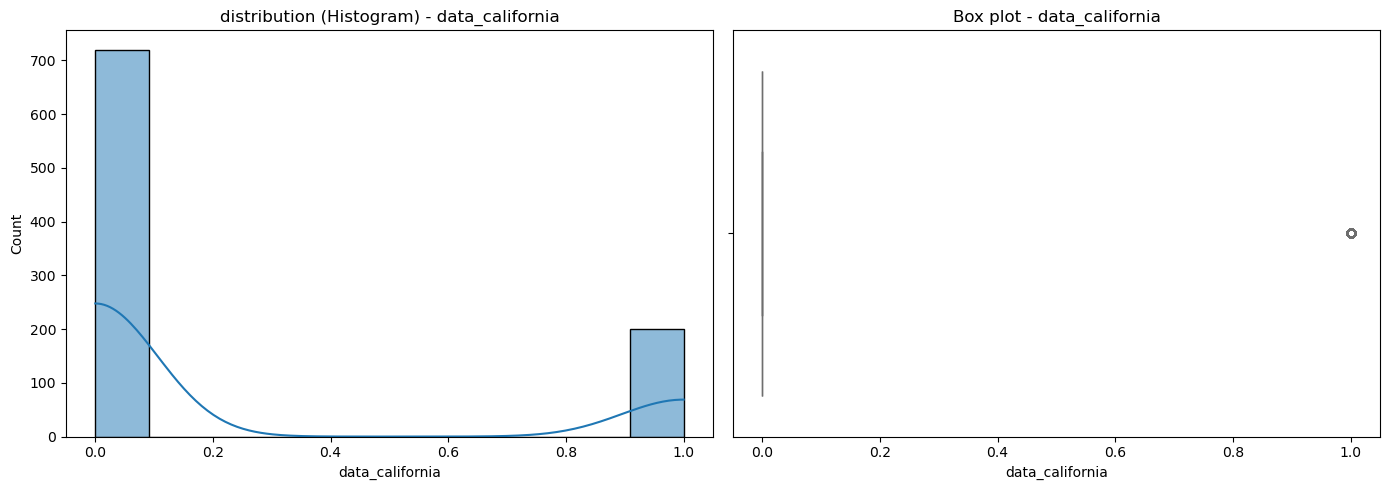

--- Analyzing column: is_symptomatic ---
count    920.000000
mean       0.460870
std        0.498738
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: is_symptomatic, dtype: float64


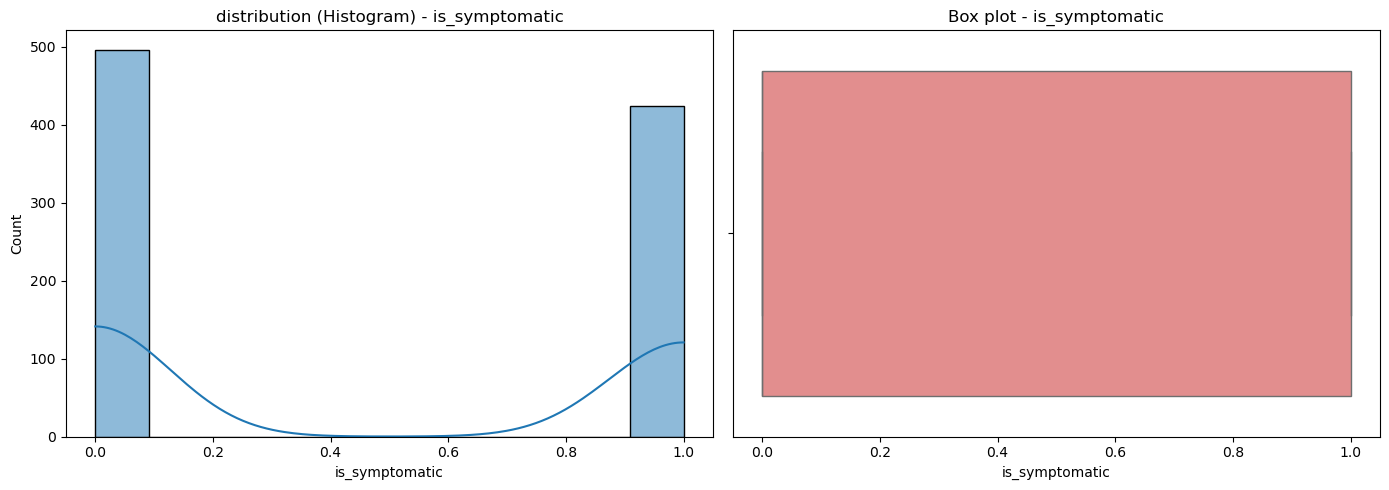

--- Analyzing column: is_anginal ---
count    920.000000
mean       0.239130
std        0.426785
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: is_anginal, dtype: float64


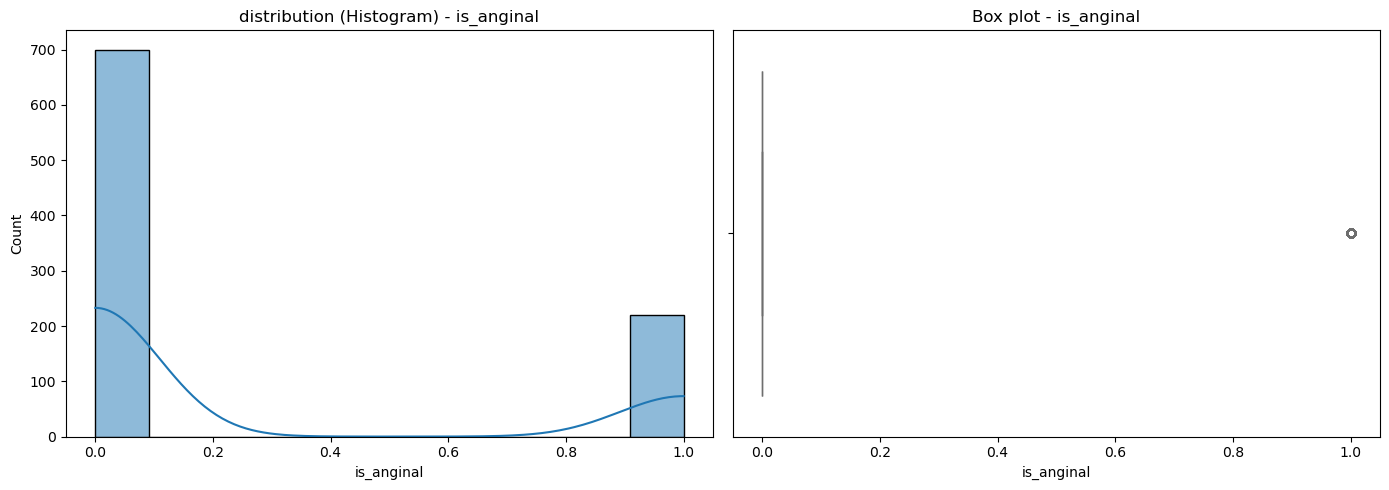

--- Analyzing column: is_typical ---
count    920.000000
mean       0.050000
std        0.218063
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: is_typical, dtype: float64


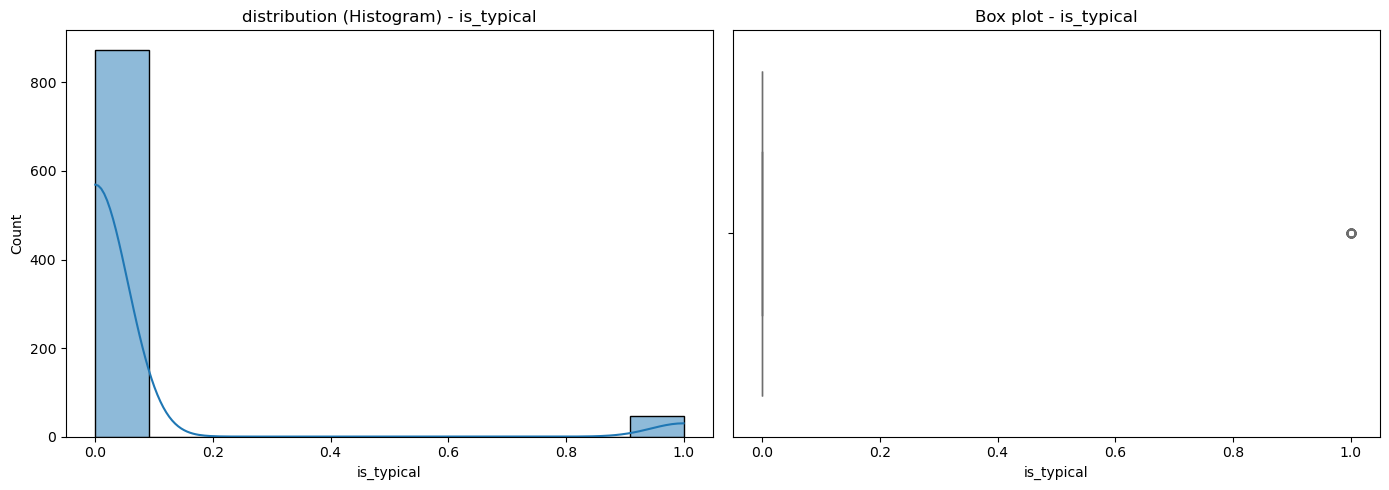

--- Analyzing column: fbs_was_missing ---
count    920.000000
mean       0.097826
std        0.297241
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: fbs_was_missing, dtype: float64


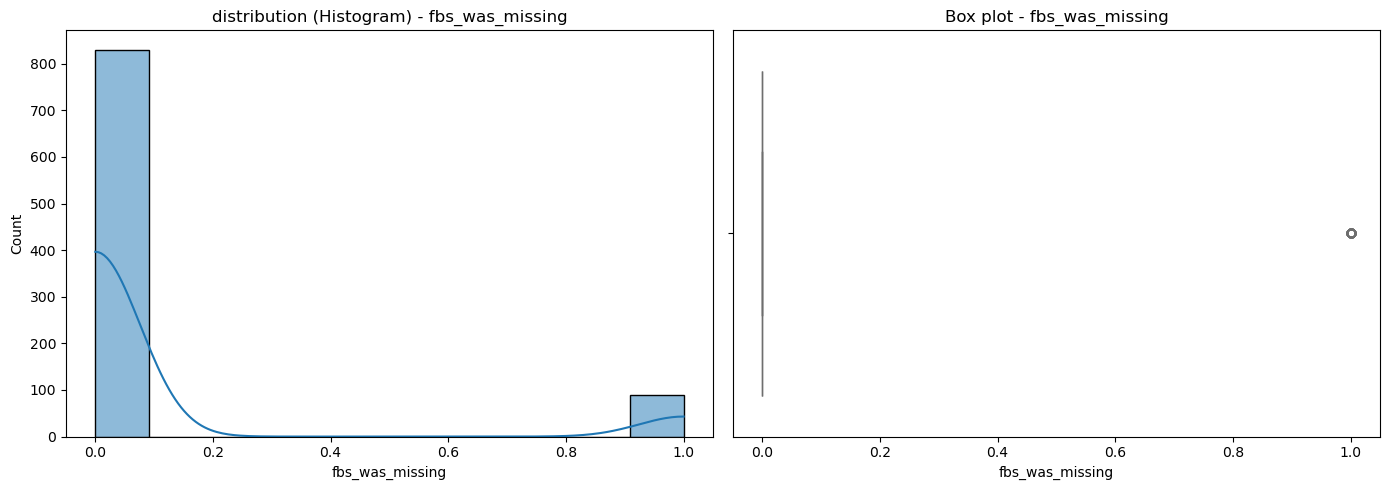

--- Analyzing column: exang_was_missing ---
count    920.000000
mean       0.059783
std        0.237213
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: exang_was_missing, dtype: float64


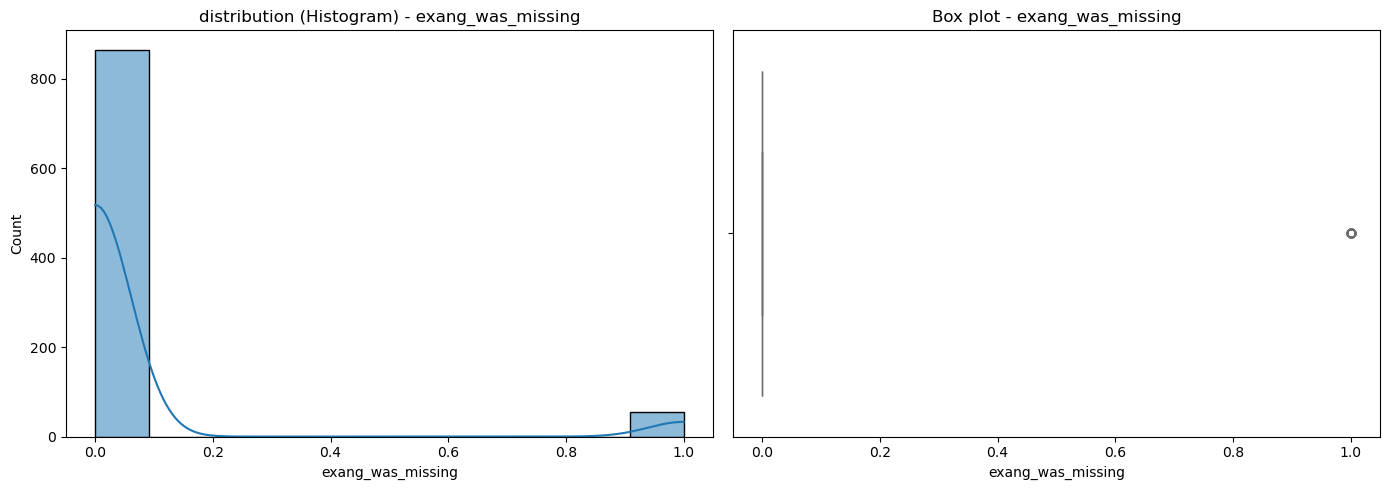

--- Analyzing column: ecg_abnormal ---
count    920.000000
mean       0.204348
std        0.403444
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: ecg_abnormal, dtype: float64


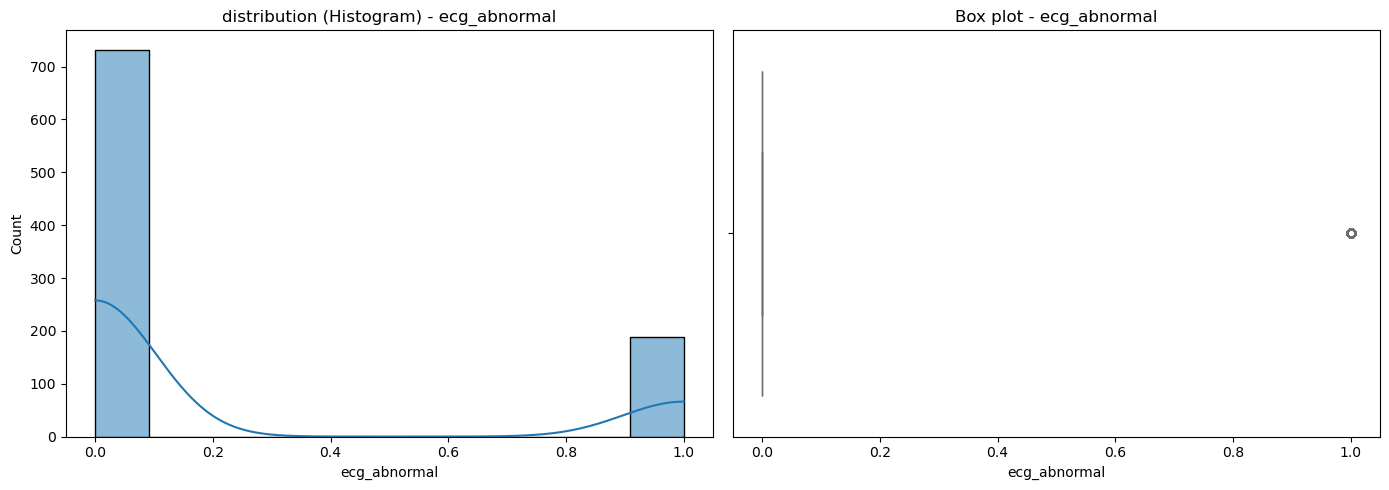

--- Analyzing column: ecg_lvh ---
count    920.000000
mean       0.204348
std        0.403444
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: ecg_lvh, dtype: float64


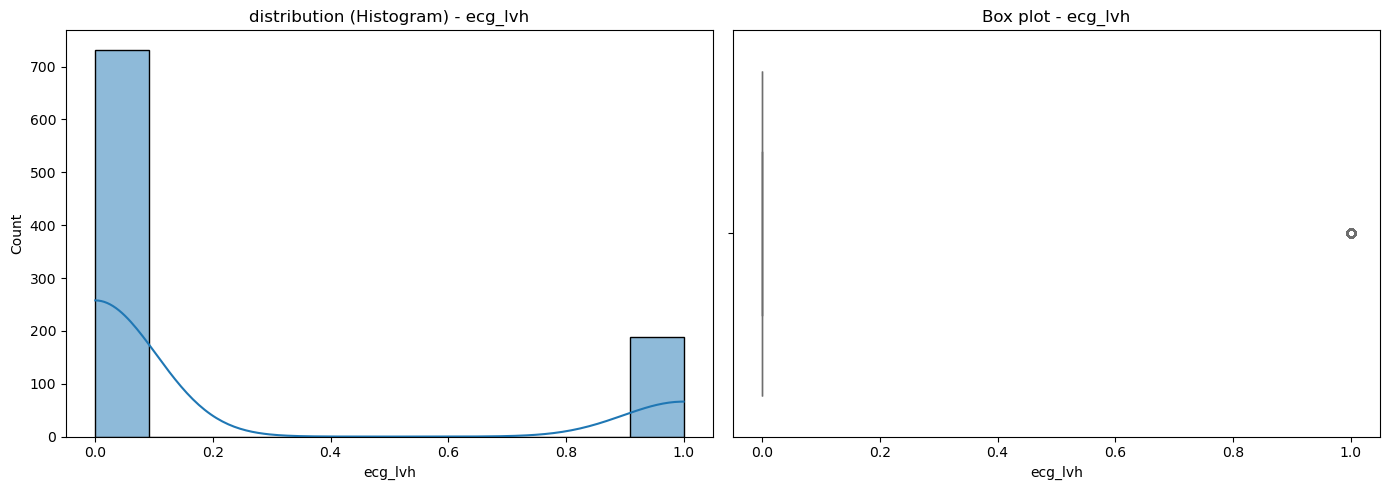

--- Analyzing column: thal_fixed_defect ---
count    920.000000
mean       0.050000
std        0.218063
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: thal_fixed_defect, dtype: float64


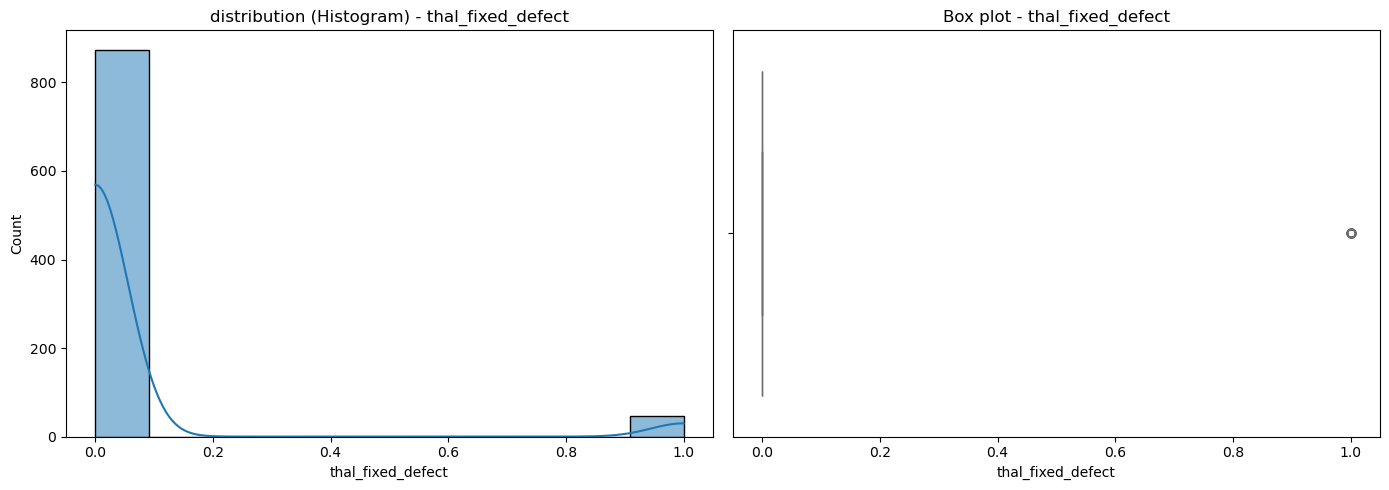

--- Analyzing column: thal_normal ---
count    920.000000
mean       0.213043
std        0.409681
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: thal_normal, dtype: float64


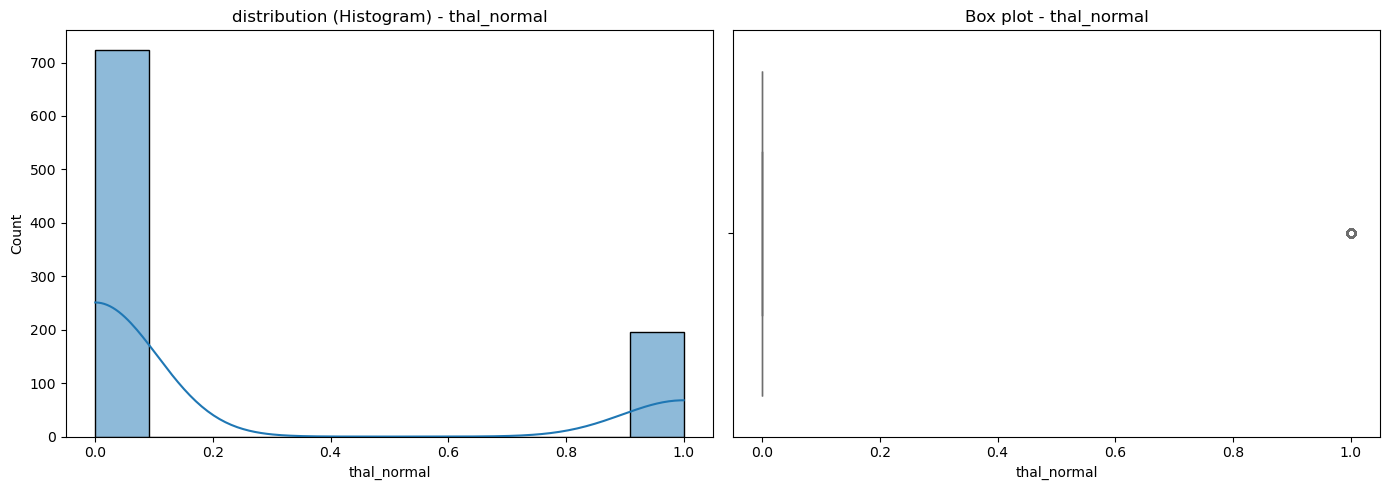

--- Analyzing column: thal_reversable_defect ---
count    920.000000
mean       0.208696
std        0.406597
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: thal_reversable_defect, dtype: float64


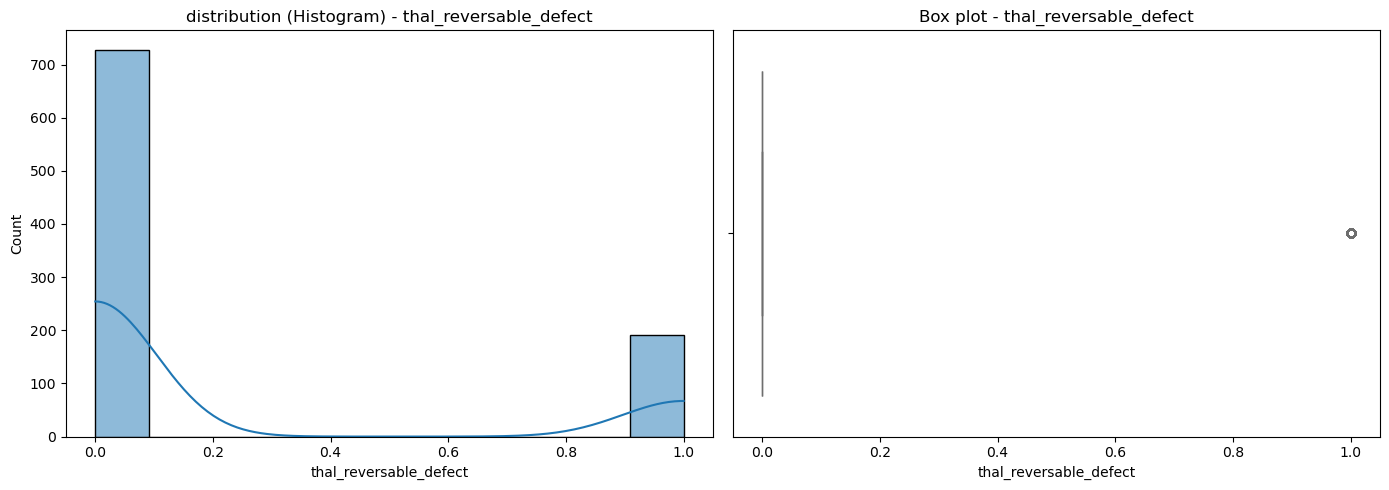

--- Analyzing column: thal_unknown ---
count    920.000000
mean       0.528261
std        0.499472
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: thal_unknown, dtype: float64


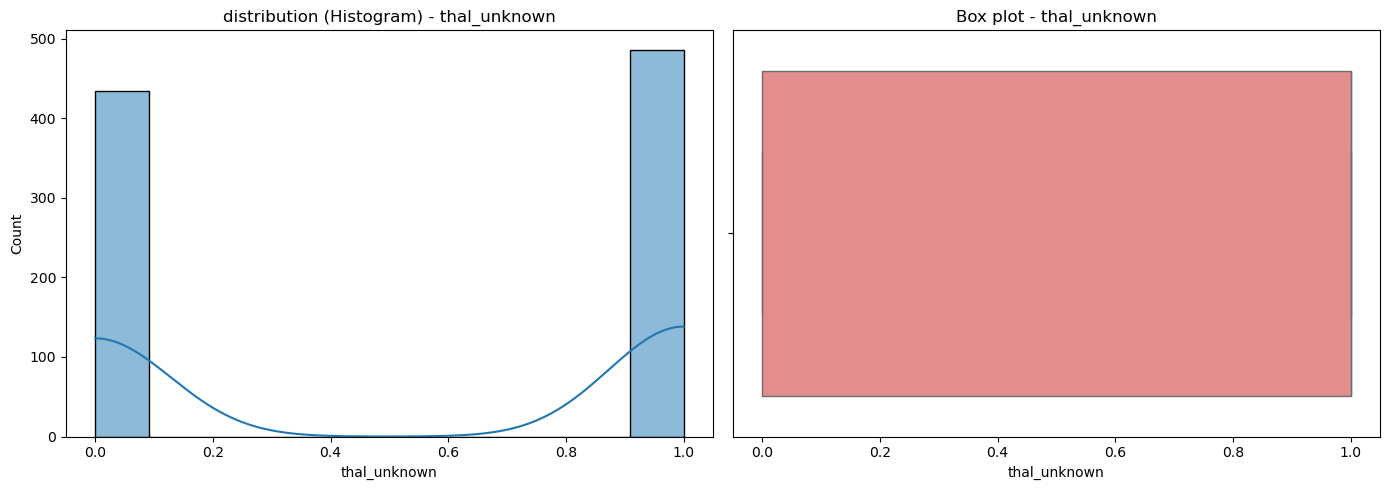

--- Analyzing column: slope_downsloping ---
count    920.000000
mean       0.068478
std        0.252702
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: slope_downsloping, dtype: float64


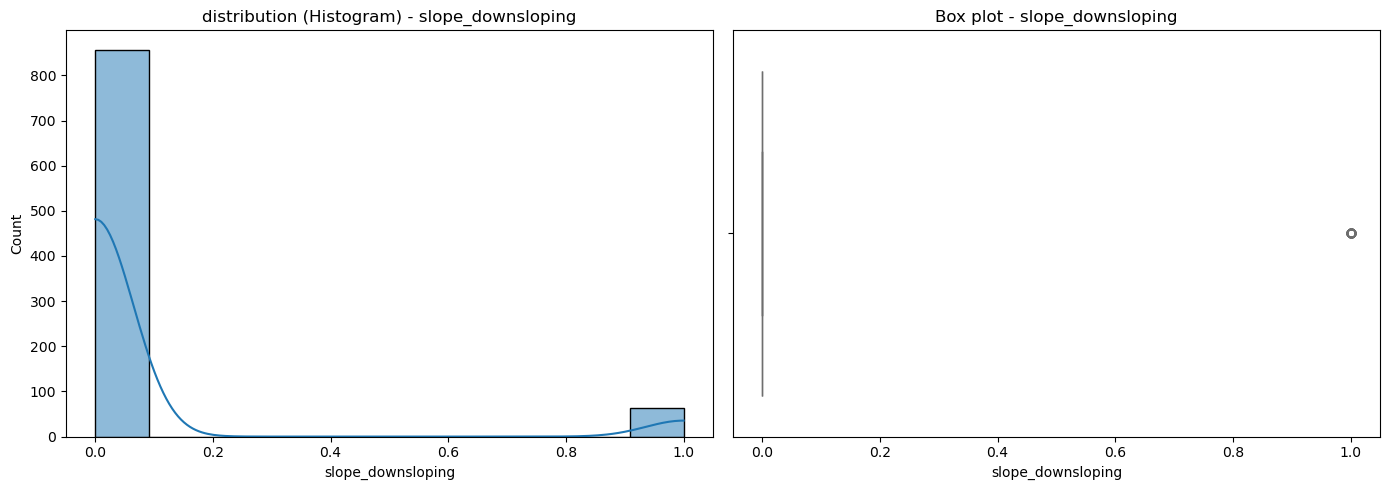

--- Analyzing column: slope_flat ---
count    920.000000
mean       0.375000
std        0.484386
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: slope_flat, dtype: float64


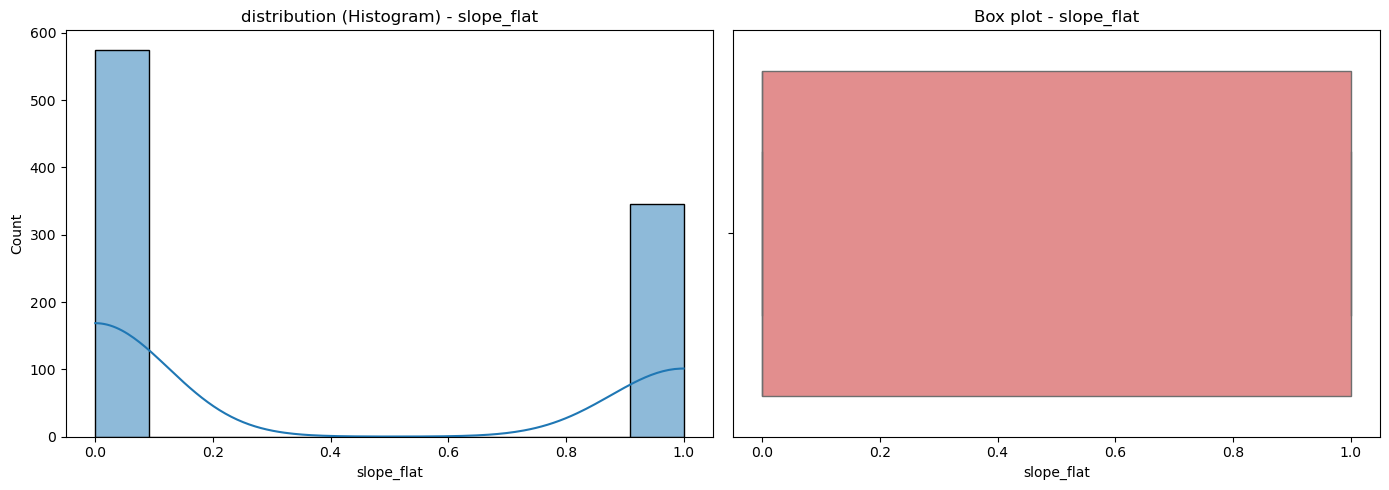

--- Analyzing column: slope_unknown ---
count    920.00000
mean       0.33587
std        0.47255
min        0.00000
25%        0.00000
50%        0.00000
75%        1.00000
max        1.00000
Name: slope_unknown, dtype: float64


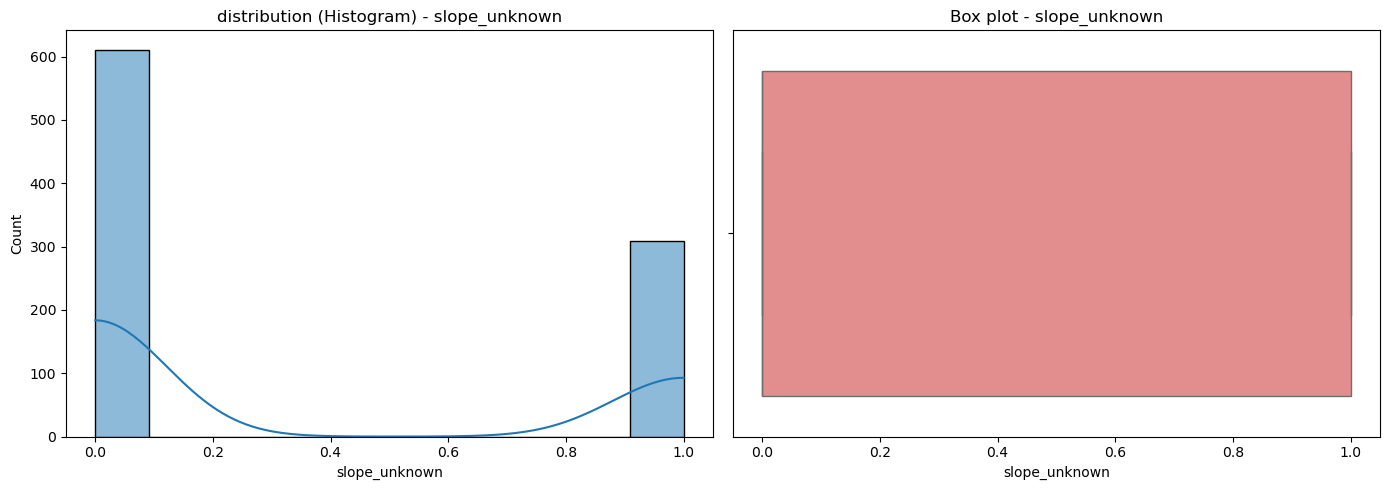

--- Analyzing column: slope_upsloping ---
count    920.000000
mean       0.220652
std        0.414912
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: slope_upsloping, dtype: float64


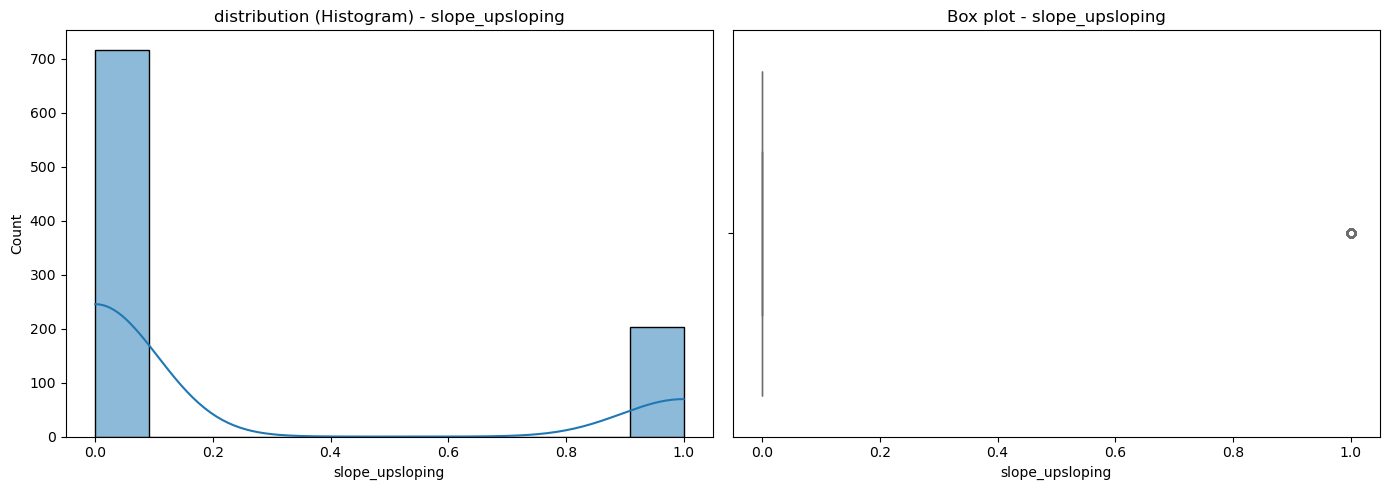

--- Analyzing column: ca_was_missing ---
count    920.00000
mean       0.66413
std        0.47255
min        0.00000
25%        0.00000
50%        1.00000
75%        1.00000
max        1.00000
Name: ca_was_missing, dtype: float64


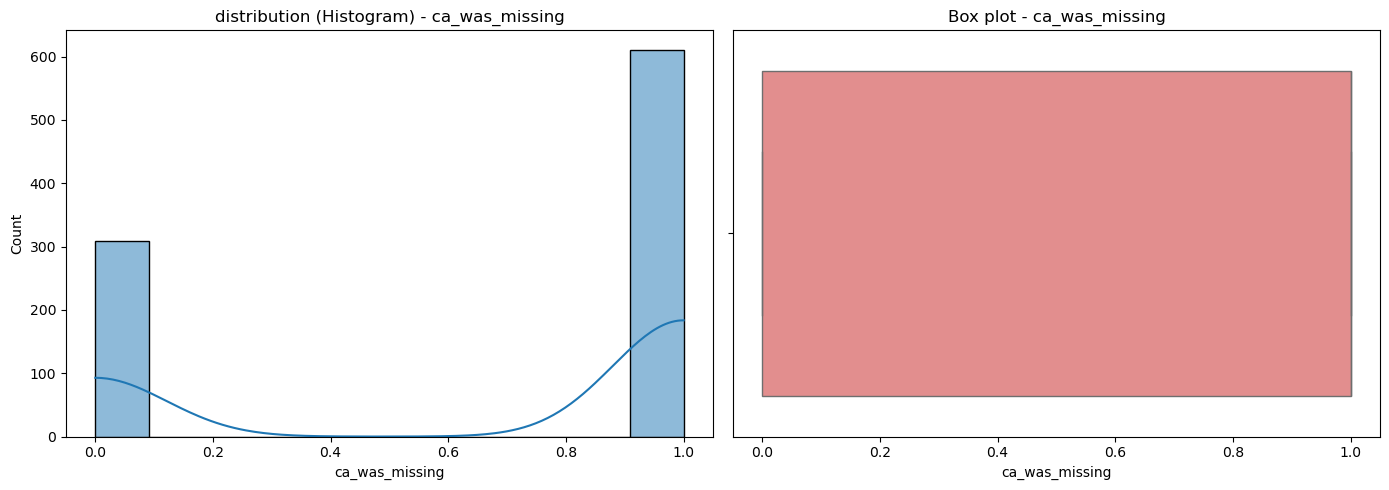

--- Analyzing column: chol_missing ---
count    920.000000
mean       0.193478
std        0.395239
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: chol_missing, dtype: float64


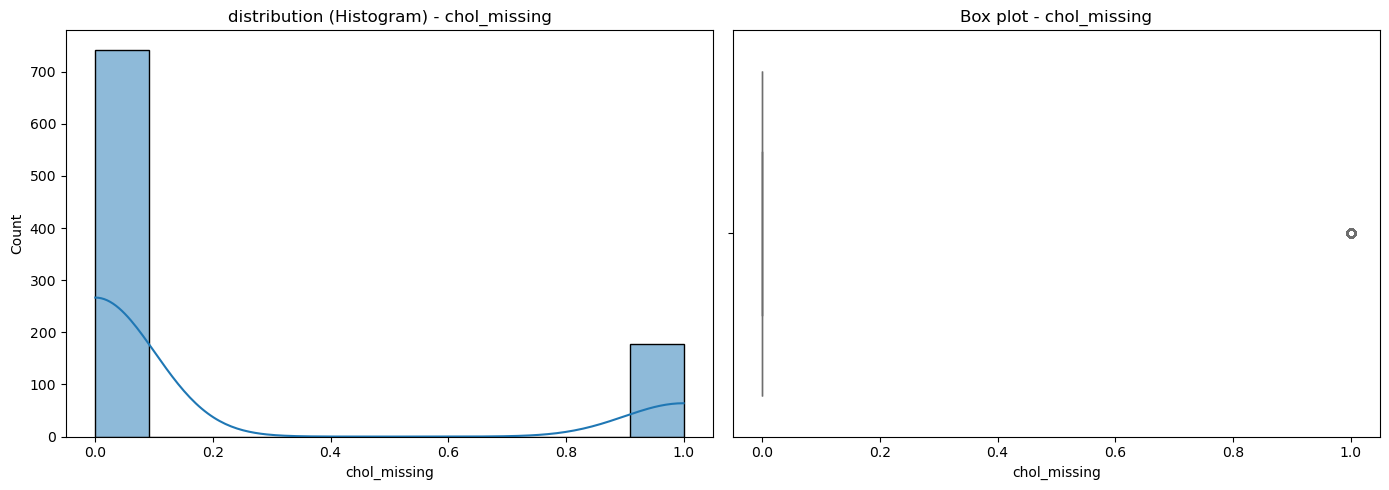

In [8]:
def analyzing_single_column(df):
    num_cols = df.columns

    for col in num_cols:
        print(f"--- Analyzing column: {col} ---")
        print(df[col].describe())
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        sns.histplot(df[col], kde=True, ax=axes[0])
        axes[0].set_title(f'distribution (Histogram) - {col}')
        
        sns.boxplot(x=df[col], ax=axes[1], color='lightcoral')
        axes[1].set_title(f'Box plot - {col}')
        
        plt.tight_layout()
        plt.show()


analyzing_single_column(data)

#### Here I simply Ctrl+C the code from cleaning_dataset part to collect more infos about the data.

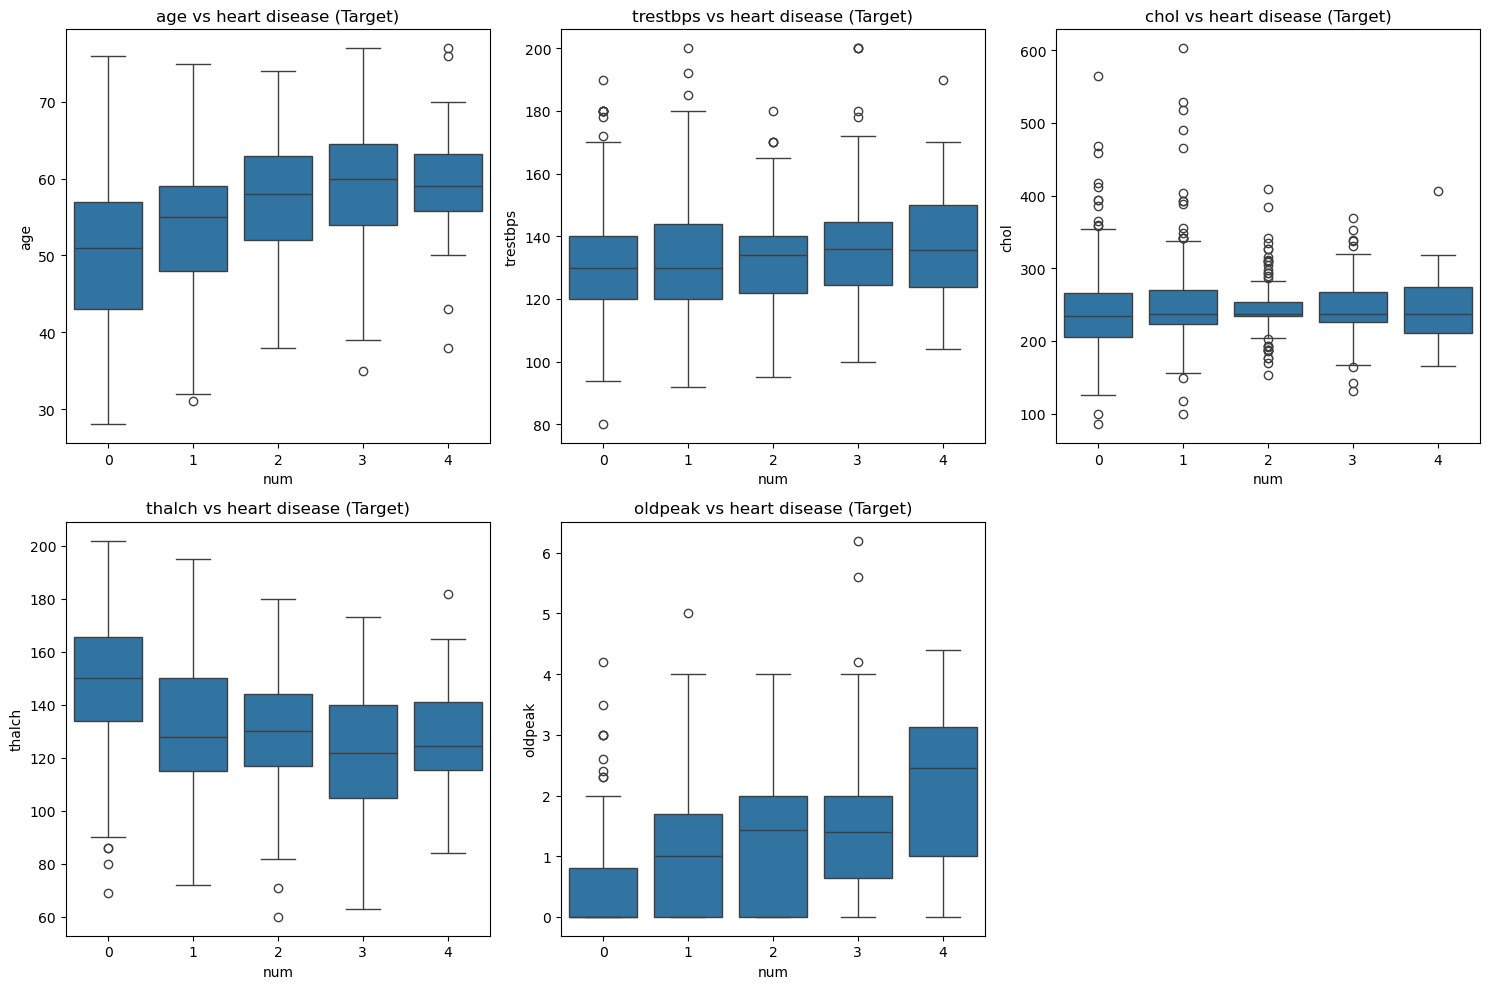

In [23]:
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='num', y=col, data=data)
    plt.title(f'{col} vs heart disease (Target)')

plt.tight_layout()
plt.show()



### Anova Statistical tests for continous numerical columns in comparison with 5 classess from target (Y).

In [25]:
for col in num_cols:
    groups = [data[data["num"] == cls][col] for cls in data["num"].unique()]
    
    f_stat, p_value = stats.f_oneway(*groups)
    
    print(f"--- Feature: {col} ---")
    print(f"F statistics: {f_stat:.4f}")
    print(f"P val: {p_value:.4f}")
    
    if p_value < 0.05:
        print("Result: There are significant difference between Target classes.")
    else:
        print("Result: No difference. Averages between classess are very similiar.")
    print("-" * 30)

--- Feature: age ---
F statistics: 31.2261
P val: 0.0000
Result: There are significant difference between Target classes.
------------------------------
--- Feature: trestbps ---
F statistics: 4.6825
P val: 0.0010
Result: There are significant difference between Target classes.
------------------------------
--- Feature: chol ---
F statistics: 2.0490
P val: 0.0856
Result: No difference. Averages between classess are very similiar.
------------------------------
--- Feature: thalch ---
F statistics: 45.4561
P val: 0.0000
Result: There are significant difference between Target classes.
------------------------------
--- Feature: oldpeak ---
F statistics: 59.4172
P val: 0.0000
Result: There are significant difference between Target classes.
------------------------------


### As we can see there appears outliers which can lessen accuracy in our model.

### Here I will plot continous variables with target variable adding regression on it for visualization

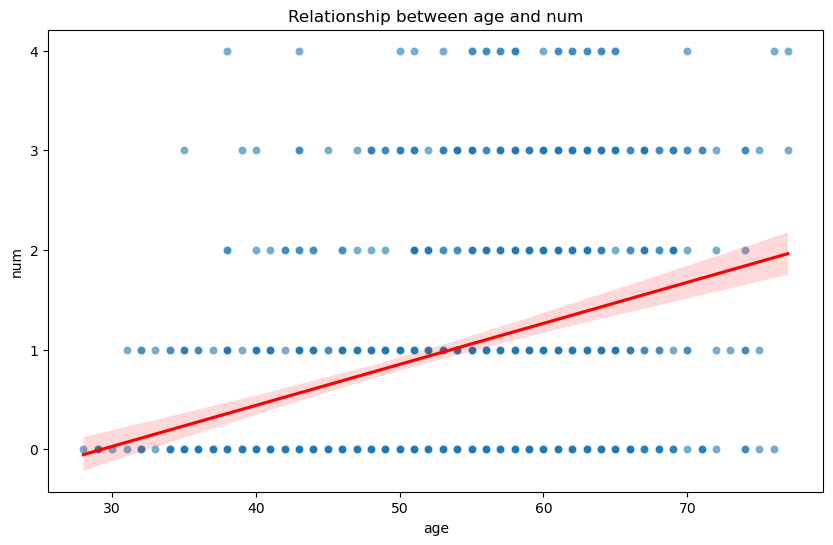

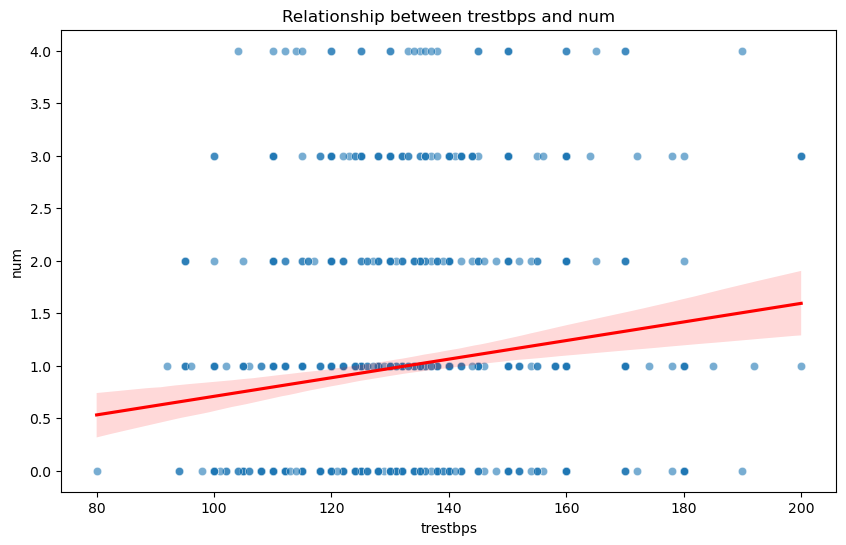

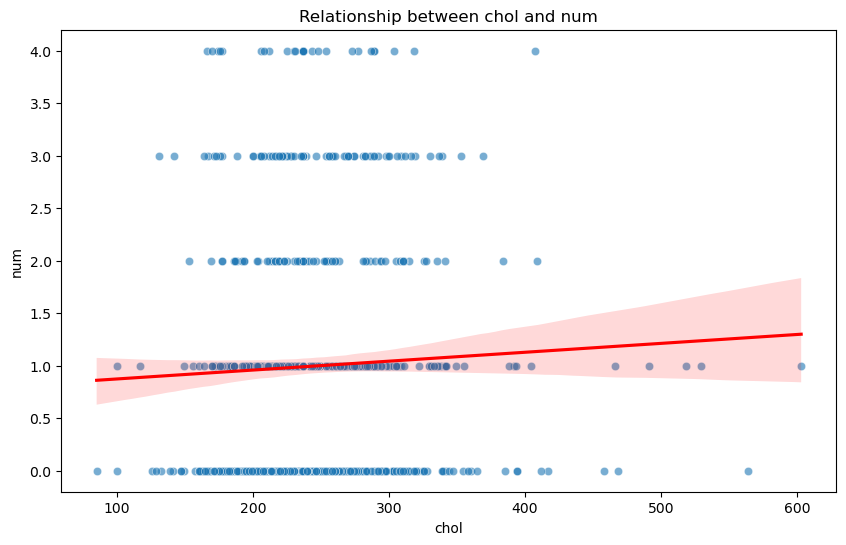

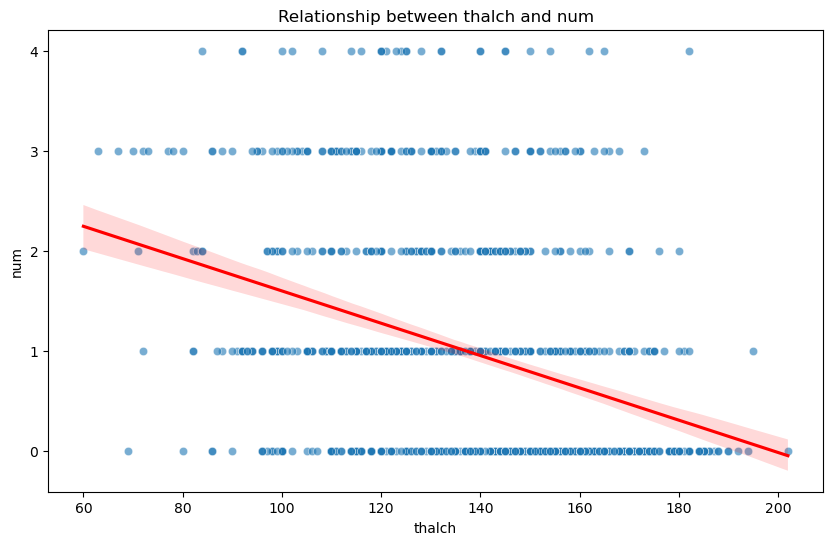

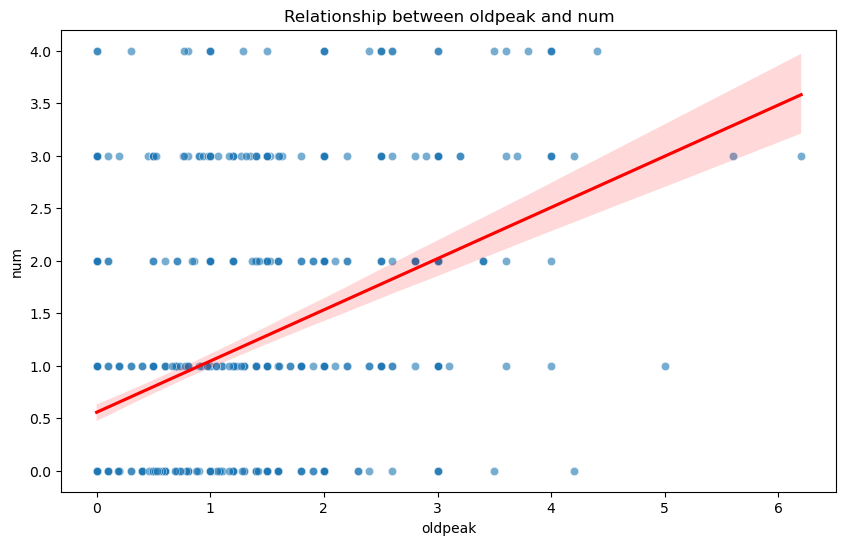

In [11]:
def plot_bivariate_num_num(df, col1, col2):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x=col1, y=col2, alpha=0.6)
    sns.regplot(data=df, x=col1, y=col2, scatter=False, color='red') 
    plt.title(f'Relationship between {col1} and {col2}')
    plt.show()

num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
for i, col in enumerate(num_cols, 1):
    plot_bivariate_num_num(data, col, "num")

### It is significant to note that colunn "chol" where Nulls were stored were filled with median

In [12]:
print("Number of values in column filled with median: ", data[data["chol"] == data['chol'].median()].groupby("num")["chol"].count())
print()
print("Number of values in column filled with real numbers: ", data[data["chol"] != 0].groupby("num")["chol"].count())


null_ratio = data[data["chol"] == data['chol'].median()].groupby("num")["chol"].count().sum() / (data[data["chol"] != 0].groupby("num")["chol"].count().sum() + data[data["chol"] == 0].groupby("num")["chol"].count().sum())
print(f"Percentage of nulls in this column is {round(null_ratio, 2) * 100}%")

Number of values in column filled with median:  num
0    22
1    65
2    47
3    38
4     6
Name: chol, dtype: int64

Number of values in column filled with real numbers:  num
0    411
1    265
2    109
3    107
4     28
Name: chol, dtype: int64
Percentage of nulls in this column is 19.0%


### In order to mark this information I will create another column called "chol_missing".

In [13]:
data['chol_missing'] = data['chol'] == data['chol'].median()

data["chol_missing"] = data["chol_missing"].astype(int)
data["chol_missing"].dtype

dtype('int64')

## Target analysis

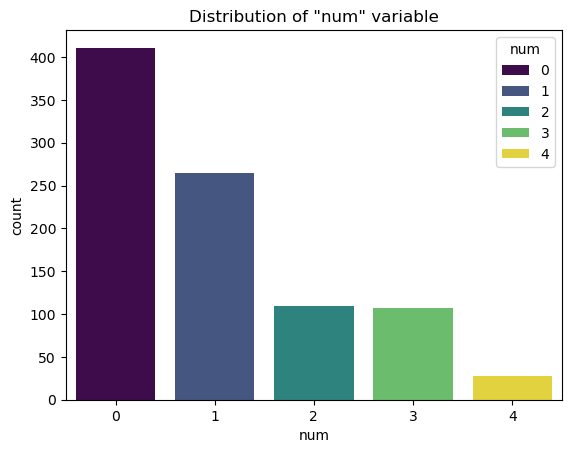

num
0    44.673913
1    28.804348
2    11.847826
3    11.630435
4     3.043478
Name: proportion, dtype: float64


In [14]:
sns.countplot(data=data, x='num', palette='viridis', hue="num")
plt.title('Distribution of "num" variable')
plt.show()

print(data['num'].value_counts(normalize=True) * 100)

## Here I want to check if the target column is about to have poisson distribution. 

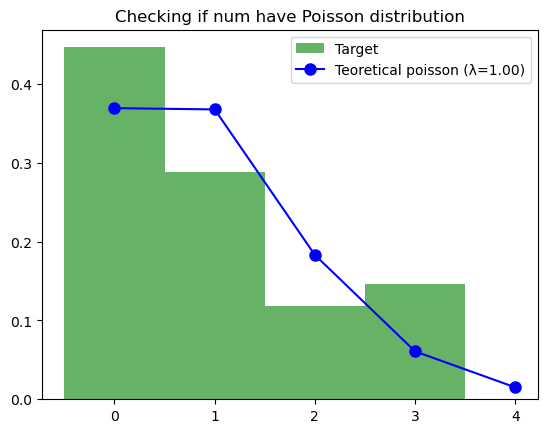

In [30]:
col = "num"
mu = data[col].mean()
bins = np.arange(0, data[col].max() + 1)

plt.hist(data[col], bins=bins, density=True, alpha=0.6, color='g', label='Target', align='left')

x = np.arange(0, data[col].max() + 1)
plt.plot(x, stats.poisson.pmf(x, mu), 'bo-', ms=8, label=f'Teoretical poisson (λ={mu:.2f})')

plt.title(f'Checking if {col} have Poisson distribution')
plt.legend()
plt.show()

## In order to prove that statistically I will perform chi-square test. However there is no clear statistical test for prove that data have poisson distribution.

In [34]:
observed_counts = data[col].value_counts().sort_index()
n_obs = observed_counts.sum()

mu = data[col].mean()
expected_probs = poisson.pmf(observed_counts.index, mu)
expected_counts = (expected_probs / expected_probs.sum()) * n_obs

stat, p_value = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Chi2: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("This target don't have Poisson distribution.")
else:
    print("Might have Poisson distrib.")

Chi2: 112.2953
P-value: 0.0000
This target don't have Poisson distribution.


## Distribution between healthy/unhealthy is 44%/56% so it is balanced.

## Here I want to show an example that kde plot may bring us some information. It suggests that certain age value is correlated with stronger heart disease risk. Healthy people tend to be younger in overall. People with the harshest heart diseases statistically tend to be older.

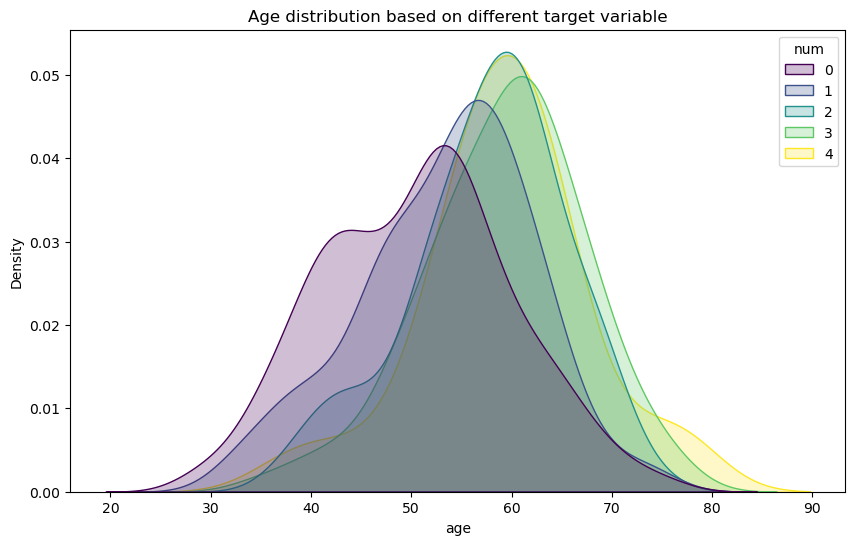

In [16]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data, x='age', hue='num', palette='viridis', fill=True, common_norm=False)
plt.title('Age distribution based on different target variable')
plt.show()

## Before the Machine Learning part I will do Spearman statistical tests based on non-linear data. 
### So let's assume that there is no any correlation between feature and our target. ( Hypothesis 0)

In [17]:
target_corr = data.corr(method='spearman')['num'].sort_values(ascending=False)

print("Dependant variable correlation with target variable (Spearman):")
print(target_corr)

Dependant variable correlation with target variable (Spearman):
num                       1.000000
oldpeak                   0.437667
exang                     0.417820
age                       0.347184
chol_missing              0.326250
data_switzerland          0.309758
slope_flat                0.295735
male                      0.293700
thal_reversable_defect    0.286907
data_california           0.244294
ca                        0.222184
fbs_was_missing           0.165165
slope_downsloping         0.164092
trestbps                  0.134760
fbs                       0.130825
thal_fixed_defect         0.110261
chol                      0.086680
ca_was_missing            0.070143
exang_was_missing         0.067974
ecg_abnormal              0.048356
ecg_lvh                   0.048356
is_typical               -0.058961
thal_unknown             -0.077656
data_cleveland           -0.079755
slope_upsloping          -0.164246
slope_unknown            -0.246680
thal_normal              -

### As we can see there are some variables with moderate correlation, so it is not clear in what direction we should aim to.

##### Spearman values are between <-1;1>. correlation: Under 0.3 ---> Weak. between 0.3 and 0.5 ----> Moderate. Above 0.5 ----> Strong. Above 0.8 ----> Very strong.

## I will choose continous variables to see the distinction between spearman and person.

In [22]:
cols_to_test = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num']

pearson_corr = data[cols_to_test].corr(method='pearson')['num'].drop('num')
spearman_corr = data[cols_to_test].corr(method='spearman')['num'].drop('num')

comparison_df = pd.DataFrame({
    'Pearson (Linear)': pearson_corr,
    'Spearman (Ranks)': spearman_corr,
    'Distinction': spearman_corr - pearson_corr
}).sort_values(by='Distinction', ascending=False)

print(comparison_df)

          Pearson (Linear)  Spearman (Ranks)  Distinction
chol              0.038925          0.086680     0.047755
age               0.339596          0.347184     0.007589
trestbps          0.139245          0.134760    -0.004484
oldpeak           0.442416          0.437667    -0.004749
thalch           -0.360859         -0.393251    -0.032392


## this distinction between this 2 tests suggests that this data from columns are linear and might lead to normal distribution. 

### I will check if this data really have normal distrib. using non-parametrical shapiro-wolf test
## Hypothesis 0 --> assuming that distribution is not normal

In [38]:
for i, col in enumerate (cols_to_test):
    stat, p_value = stats.shapiro(data[col])

    print(f"\n ------ Column {col }------")
    print(f'Test statistics: {stat:.4f}')
    print(f'p-val: {p_value:.4f}')
    
    alpha = 0.05
    if p_value > alpha:
        print("Distribution looks normal")
    else:
        print("Distribution is NOT normal")


 ------ Column age------
Test statistics: 0.9911
p-val: 0.0000
Distribution is NOT normal

 ------ Column trestbps------
Test statistics: 0.9701
p-val: 0.0000
Distribution is NOT normal

 ------ Column chol------
Test statistics: 0.8993
p-val: 0.0000
Distribution is NOT normal

 ------ Column thalch------
Test statistics: 0.9919
p-val: 0.0001
Distribution is NOT normal

 ------ Column oldpeak------
Test statistics: 0.8301
p-val: 0.0000
Distribution is NOT normal

 ------ Column num------
Test statistics: 0.8002
p-val: 0.0000
Distribution is NOT normal


## Now i will plot quantile's of cols_to_test array.

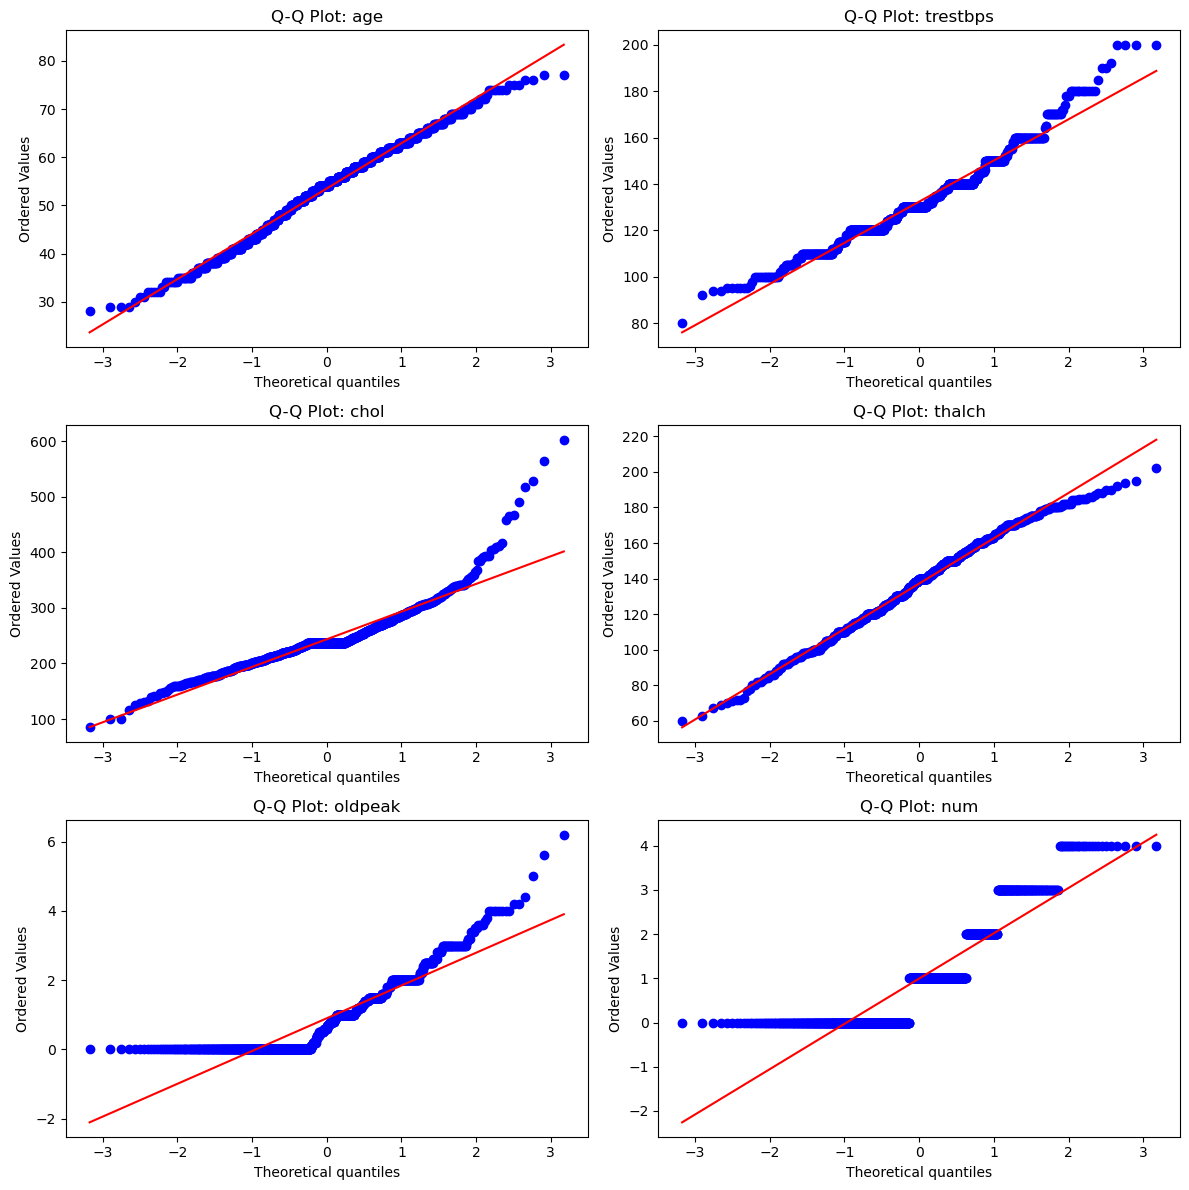

In [35]:
n_cols_list = len(cols_to_test)
fig, axes = plt.subplots(nrows=(n_cols_list + 1) // 2, ncols=2, figsize=(12, n_cols_list * 2))
axes = axes.flatten()

for i, col in enumerate(cols_to_test):
    stats.probplot(data[col], dist="norm", plot=axes[i])
    
    axes[i].set_title(f'Q-Q Plot: {col}')
    axes[i].get_lines()[0].set_markerfacecolor('blue')
    axes[i].get_lines()[1].set_color('red')           
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Few columns tend to have normal distribution

In [21]:
data.to_csv("dataset/dataset.csv", index=False)